In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

In [4]:
# ============================================
# 🔹 Funções utilitárias
# ============================================


def smart_image_download(url):
    """Baixa imagens com headers otimizados e redimensiona mantendo qualidade"""
    try:
        headers = {
            'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64)',
            'Accept': 'image/webp,image/apng,image/*,*/*;q=0.8'
        }
        response = requests.get(url, headers=headers, timeout=10)
        response.raise_for_status()
        img = Image.open(BytesIO(response.content)).convert("RGB")
        if img.width < 200:
            img = img.resize((250, 375), Image.LANCZOS)
        return img
    except Exception:
        return None


def create_book_placeholder(rating):
    """Cria placeholder visual baseado no rating"""
    if rating >= 5.0:
        return '#FFF9C4', '#FF6F00', '⭐'
    if rating >= 4.5:
        return '#E3F2FD', '#1565C0', '📘'
    if rating >= 4.0:
        return '#E8F5E8', '#2E7D32', '📗'
    return '#FCE4EC', '#C2185B', '📙'


# ============================================
# 🔹 Núcleo do sistema
# ============================================


def working_recommendations_with_images(book_title, df, n=5):
    """Gera e exibe recomendações com tratamento visual"""
    book_title = str(book_title).strip()

    if book_title not in df["Book-Title"].values:
        print(f"❌ Livro '{book_title}' não encontrado")
        similar = df[df['Book-Title'].str.contains(book_title, case=False, na=False)]
        if not similar.empty:
            print("\n💡 Talvez você quis dizer:")
            print(similar['Book-Title'].head(3).to_string(index=False))
        return None

    book = df.loc[df['Book-Title'] == book_title].iloc[0]
    print(f"\n🎯 LIVRO SELECIONADO:\n📖 {book_title}\n👤 {book['Book-Author']}\n⭐ {book['avg_ratings']:.1f} • 📊 {book['num_ratings']} avaliações")
    print("\n🔍 Buscando recomendações...")

    filtro = ~df['Book-Title'].str.contains('Harry Potter', case=False, na=False) if 'harry potter' in book_title.lower() else df['Book-Title'] != book_title
    recs = df[filtro].sort_values(['num_ratings', 'avg_ratings'], ascending=[False, False]).head(n)

    exibir_recomendacoes(recs, book_title, "autores diferentes" if 'harry potter' in book_title.lower() else "livros populares")
    return recs


def exibir_recomendacoes(recs, original, metodo):
    """Exibe imagens ou placeholders das recomendações"""
    n = len(recs)
    print(f"\n🎁 RECOMENDAÇÕES ({metodo.upper()})\n{'=' * 60}")

    fig, axes = plt.subplots(1, n, figsize=(n * 3.2, 5), dpi=120)
    axes = [axes] if n == 1 else axes

    for ax, (_, row) in zip(axes, recs.iterrows()):
        title, author, rating, num, url = row['Book-Title'], row['Book-Author'], row['avg_ratings'], row['num_ratings'], row['Image-URL-L']
        print(f"{title}\n   👤 {author}\n   ⭐ {rating:.1f} • 📊 {num} avaliações")

        img = smart_image_download(url)
        if img:
            ax.imshow(img)
        else:
            bg, color, emoji = create_book_placeholder(rating)
            placeholder = Image.new('RGB', (250, 375), color=bg)
            ax.imshow(placeholder)
            ax.text(0.5, 0.6, emoji, ha='center', va='center', transform=ax.transAxes, fontsize=40)
            ax.text(0.5, 0.3, f"⭐ {rating:.1f}", ha='center', va='center', transform=ax.transAxes, fontsize=12, weight='bold', color=color)

        ax.axis('off')
        short = (title[:25] + "...") if len(title) > 25 else title
        ax.set_title(f"{short}\npor {author.split()[-1]}", fontsize=10, pad=15, color='darkblue', weight='bold')

    plt.suptitle(f"📚 Recomendações baseadas em: {original}", fontsize=15, y=1.03, color='darkred', weight='bold')
    plt.tight_layout()
    plt.show()


# ============================================
# 🔹 Versão robusta (fallback texto)
# ============================================


def robust_recommendations(book_title, df, n=5):
    """Executa recomendação com fallback automático para modo texto"""
    try:
        return working_recommendations_with_images(book_title, df, n)
    except Exception as e:
        print(f"⚠️ Erro com imagens: {e}\n🔄 Usando modo texto...")
        return text_only_recommendations(book_title, df, n)


def text_only_recommendations(book_title, df, n=5):
    """Recomendações somente em texto"""
    if book_title not in df["Book-Title"].values:
        print(f"❌ Livro não encontrado: {book_title}")
        return None

    book = df.loc[df['Book-Title'] == book_title].iloc[0]
    print(f"\n🎯 RECOMENDAÇÕES PARA: {book_title}\n👤 {book['Book-Author']}\n⭐ {book['avg_ratings']:.1f}\n{'=' * 60}")

    filtro = ~df['Book-Title'].str.contains('Harry Potter', case=False, na=False) if 'harry potter' in book_title.lower() else df['Book-Title'] != book_title
    recs = df[filtro].nlargest(n, 'num_ratings')

    for i, (_, row) in enumerate(recs.iterrows(), 1):
        print(f"\n{i}. {row['Book-Title']}\n   👤 {row['Book-Author']}\n   ⭐ {row['avg_ratings']:.1f} • 📊 {row['num_ratings']} avaliações\n   🏷️ {row['Image-URL-L']}")
    return recs

In [5]:
# 🔧 Alta resolução para gráficos e imagens em notebooks
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 200
plt.rcParams['savefig.dpi'] = 300
print('High-res: OK (figure.dpi=200, savefig.dpi=300)')

High-res: OK (figure.dpi=200, savefig.dpi=300)


In [6]:
books = pd.read_csv('../arquivos/Books.csv')
users = pd.read_csv('../arquivos/Users.csv')
ratings = pd.read_csv('../arquivos/Ratings.csv')

In [7]:
books.head(3)

,ISBN,Book-Title,Book-Author,Year-Of-Publication,Publisher,Image-URL-S,Image-URL-M,Image-URL-L
0,0195153448,Classical Mythology,Mark P. O. Morford,2002,Oxford University Press,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...,http://images.amazon.com/images/P/0195153448.0...
1,0002005018,Clara Callan,Richard Bruce Wright,2001,HarperFlamingo Canada,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...,http://images.amazon.com/images/P/0002005018.0...
2,0060973129,Decision in Normandy,Carlo D'Este,1991,HarperPerennial,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...,http://images.amazon.com/images/P/0060973129.0...


In [8]:
users.head(3)

,User-ID,Location,Age
0,1,"nyc, new york, usa",NaN
1,2,"stockton, california, usa",18.0
2,3,"moscow, yukon territory, russia",NaN


In [9]:
ratings.head(3)

,User-ID,ISBN,Book-Rating
0,276725,034545104X,0
1,276726,0155061224,5
2,276727,0446520802,0


In [10]:
books[['Book-Title']].duplicated().sum()

29225

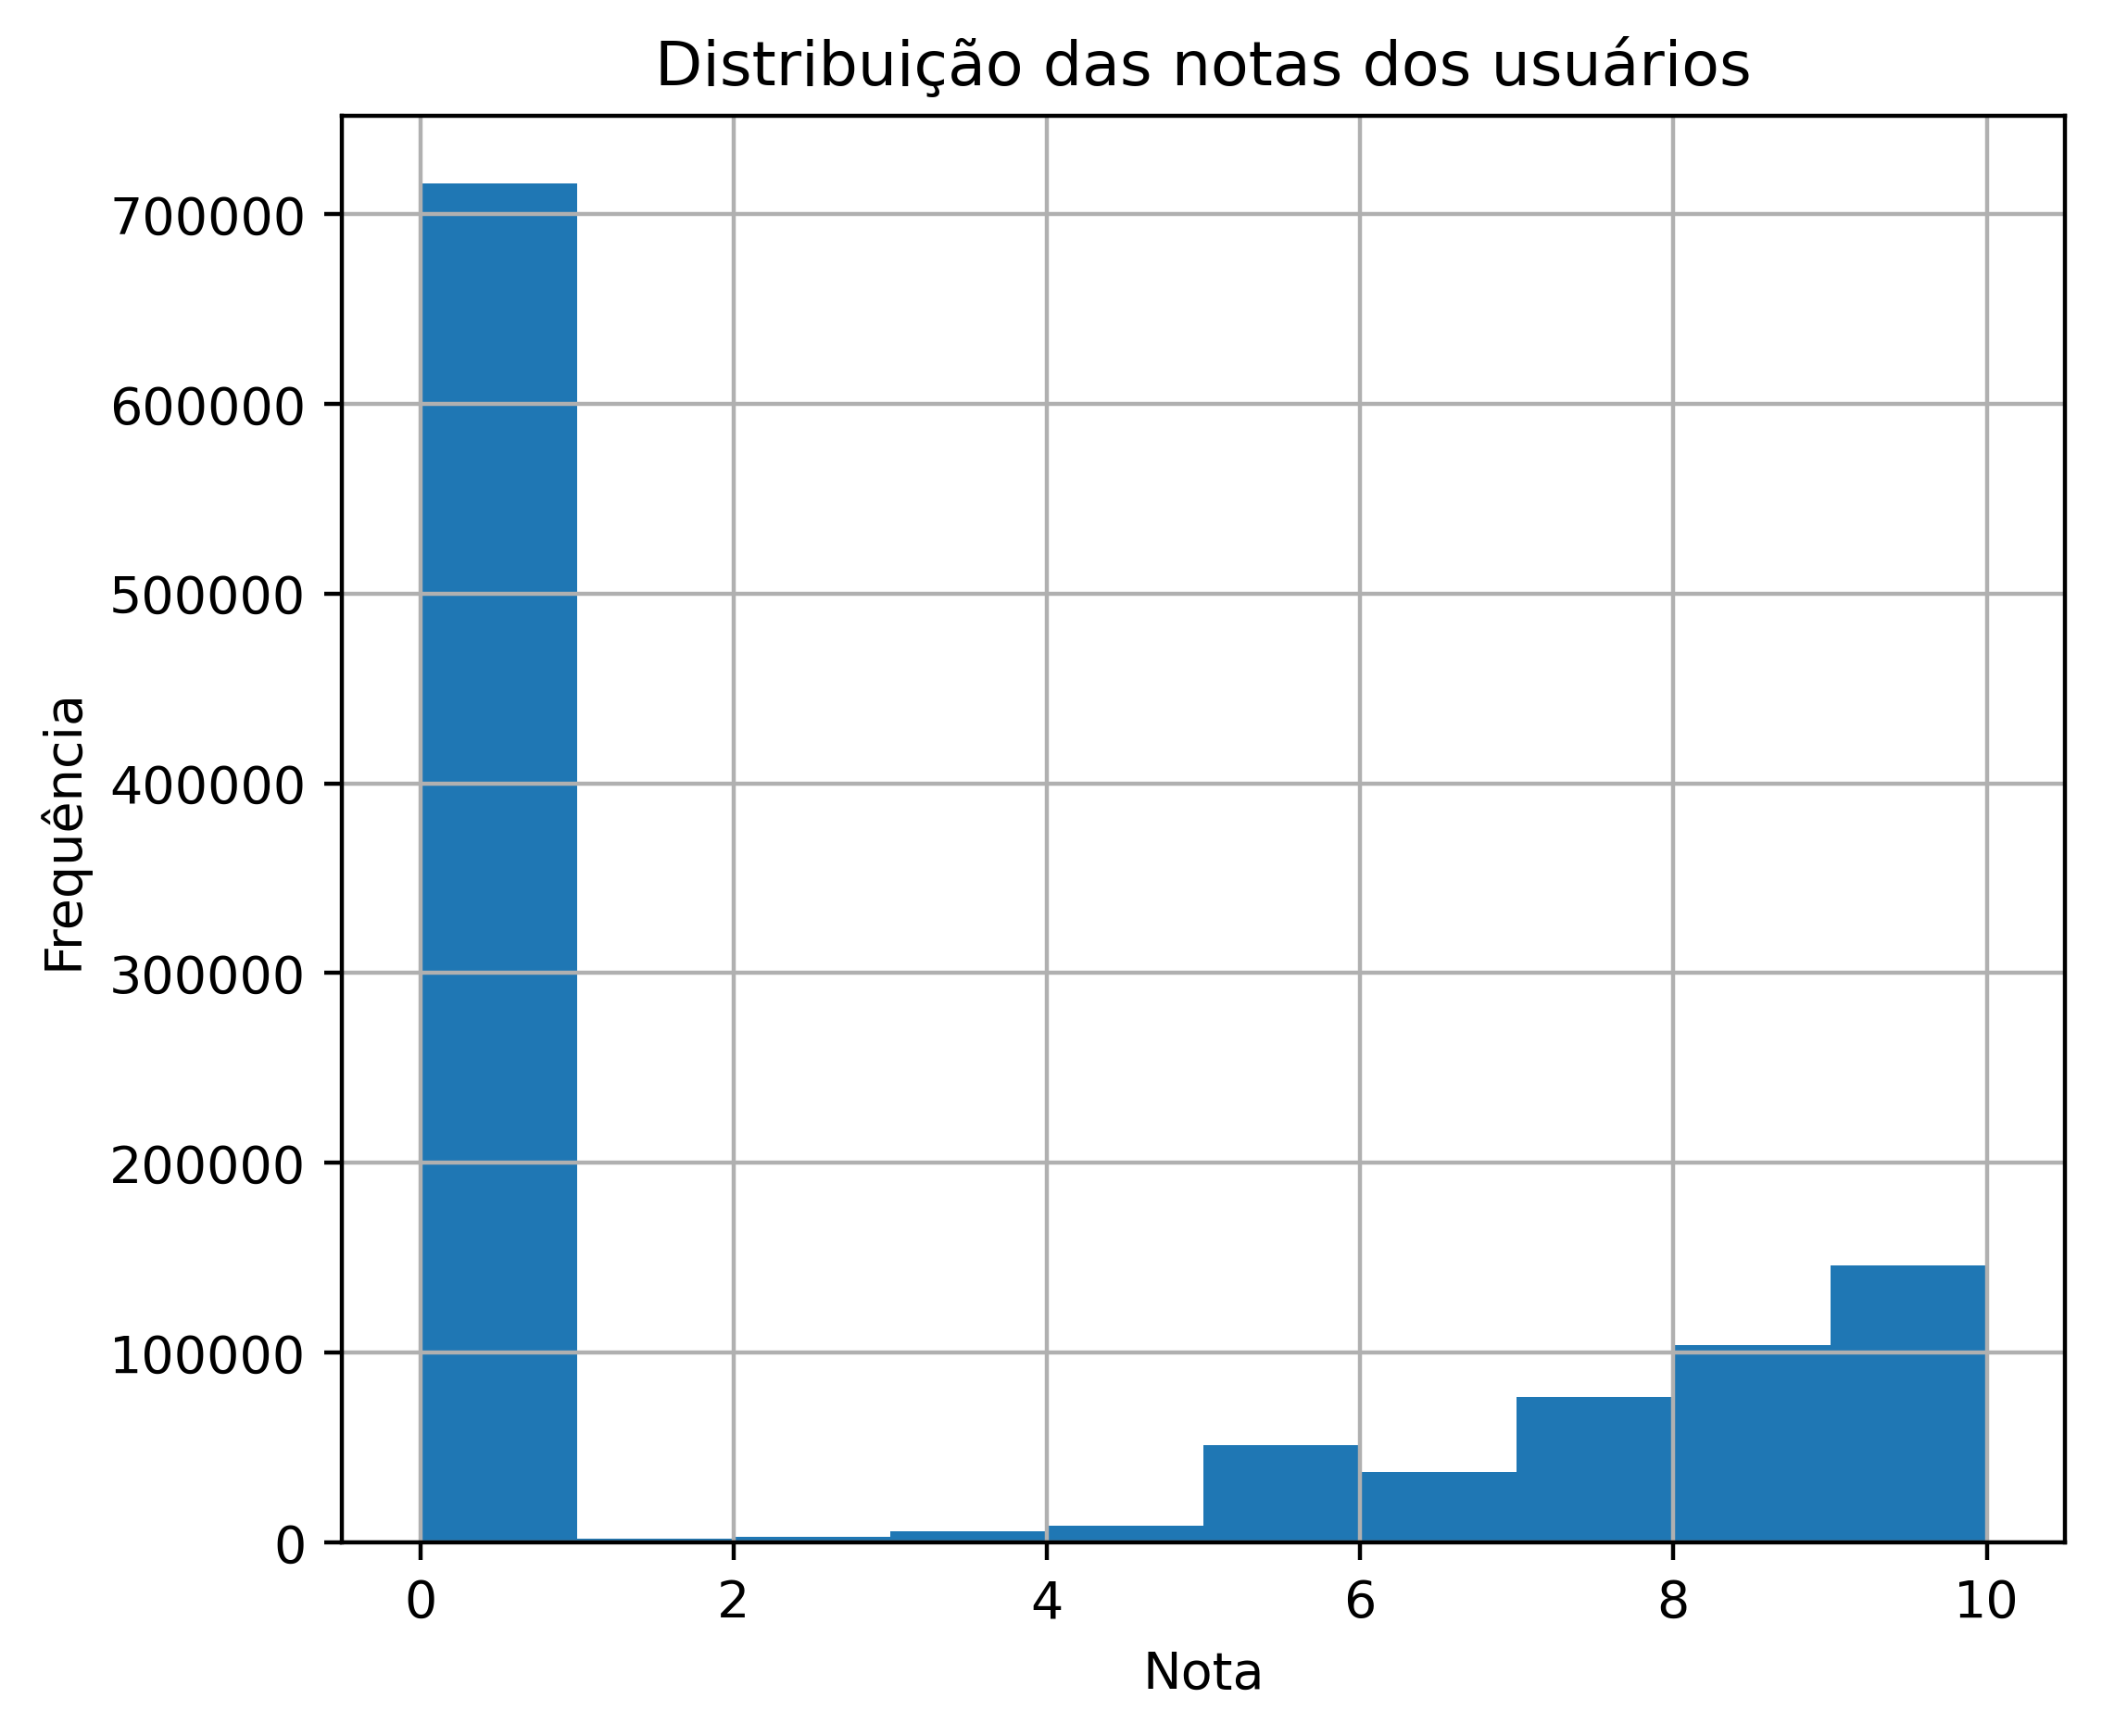

In [44]:
# ==============================================
# 1. Distribuição das notas
# ==============================================
plt.figure(figsize=(6,5))
plt.hist(ratings['Book-Rating'], bins=10)
plt.xlabel("Nota")
plt.ylabel("Frequência")
plt.title("Distribuição das notas dos usuários")
plt.grid(True)
plt.show()

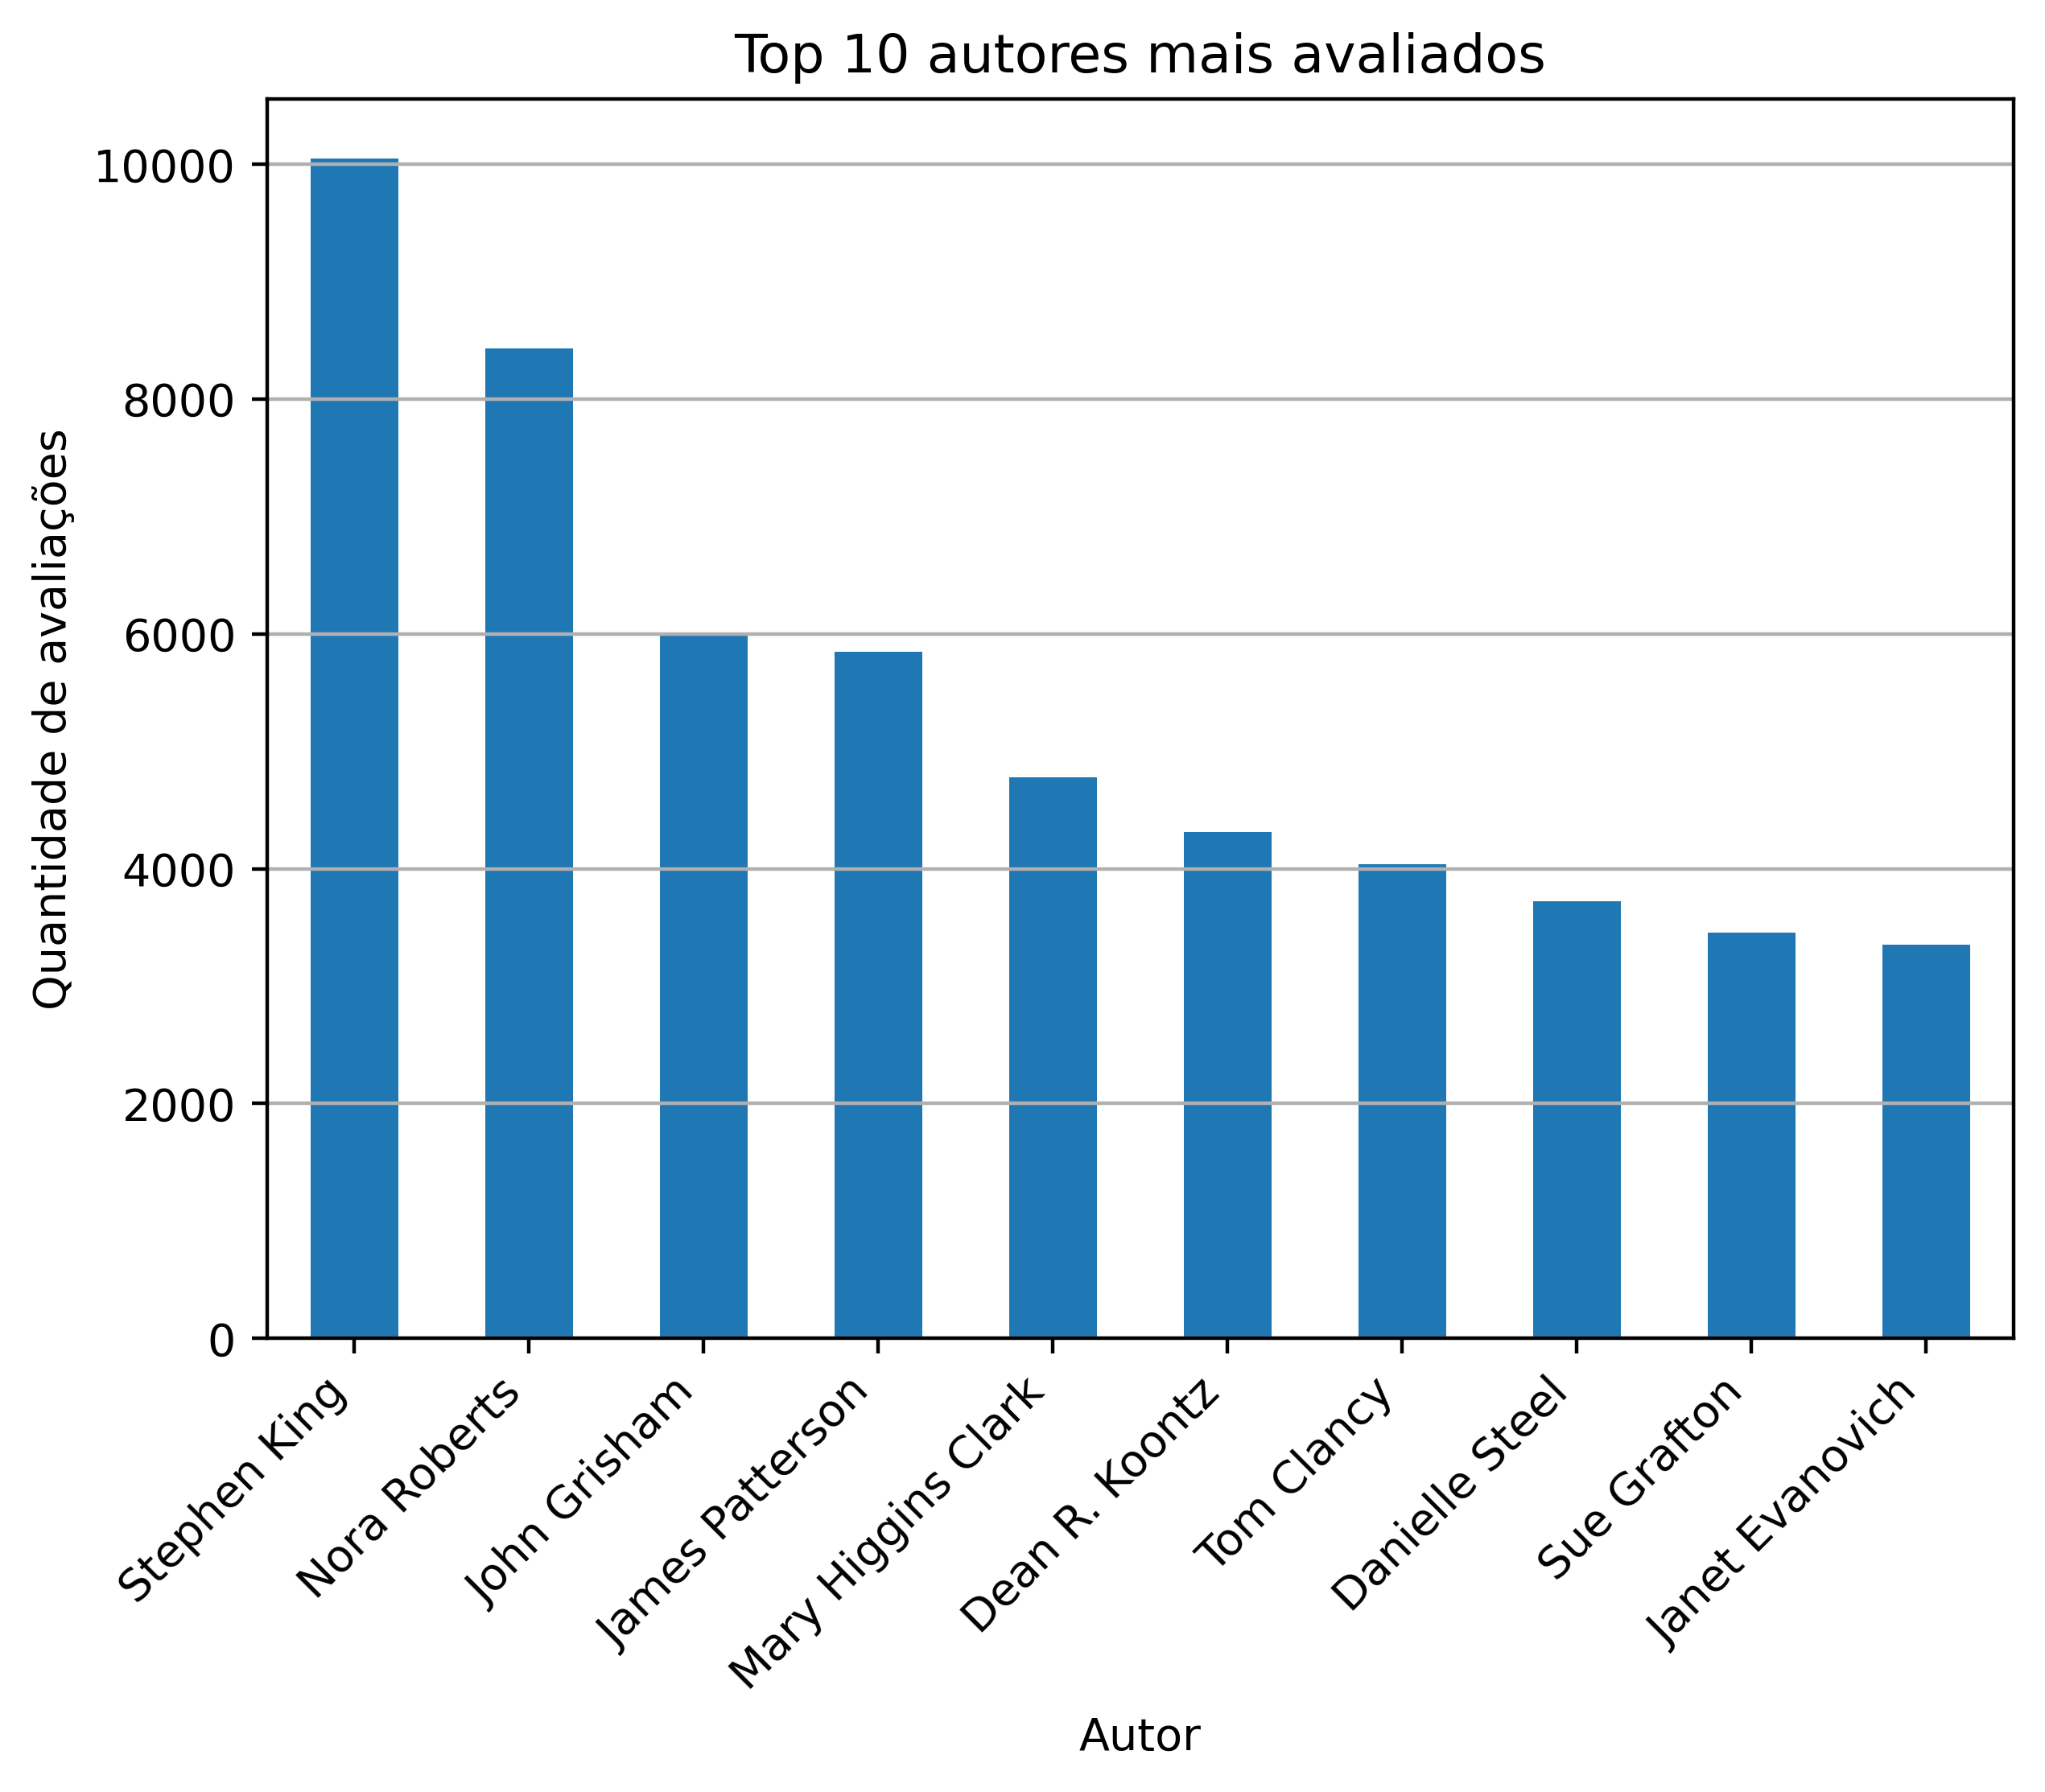

In [47]:
# ==============================================
# 4. Top autores mais avaliados
# ==============================================
top_authors = ratings_with_name['Book-Author'].value_counts().head(10)

plt.figure(figsize=(7,5))
top_authors.plot(kind='bar')
plt.xlabel("Autor")
plt.ylabel("Quantidade de avaliações")
plt.title("Top 10 autores mais avaliados")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.show()

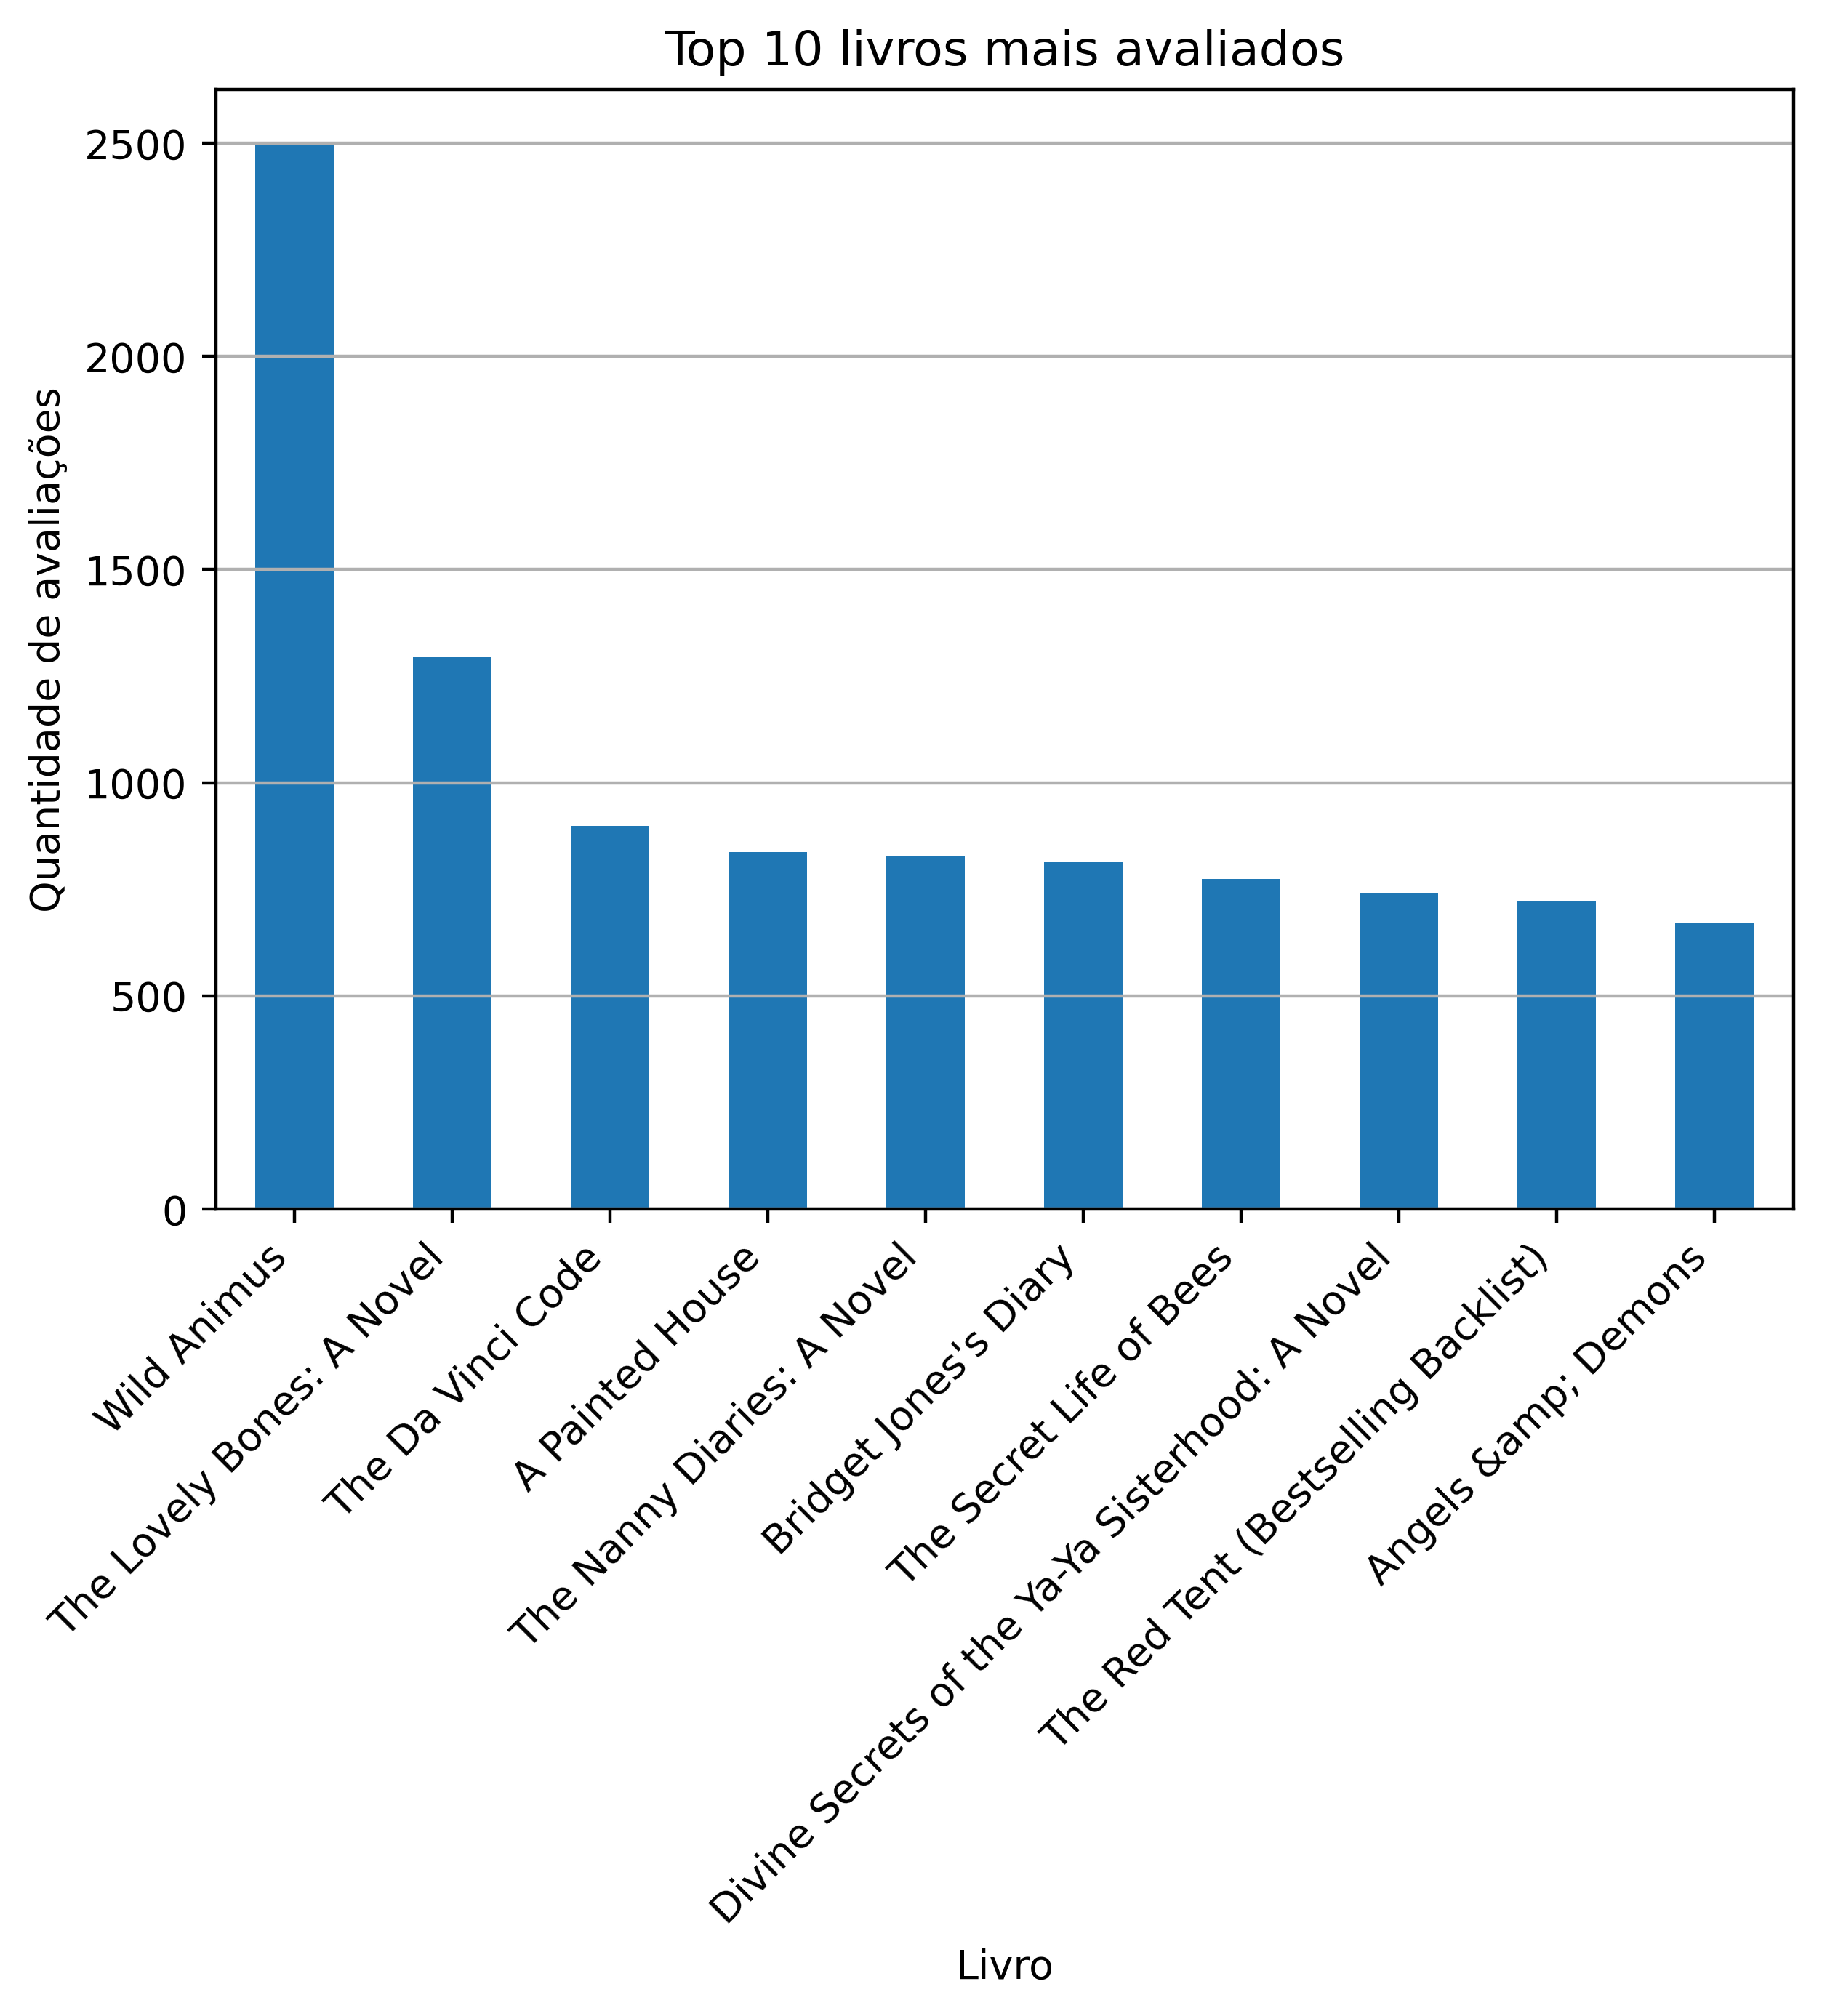

In [48]:
# ==============================================
# 5. Top livros mais avaliados
# ==============================================
top_books = ratings_with_name['Book-Title'].value_counts().head(10)

plt.figure(figsize=(7,5))
top_books.plot(kind='bar')
plt.xlabel("Livro")
plt.ylabel("Quantidade de avaliações")
plt.title("Top 10 livros mais avaliados")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y')
plt.show()

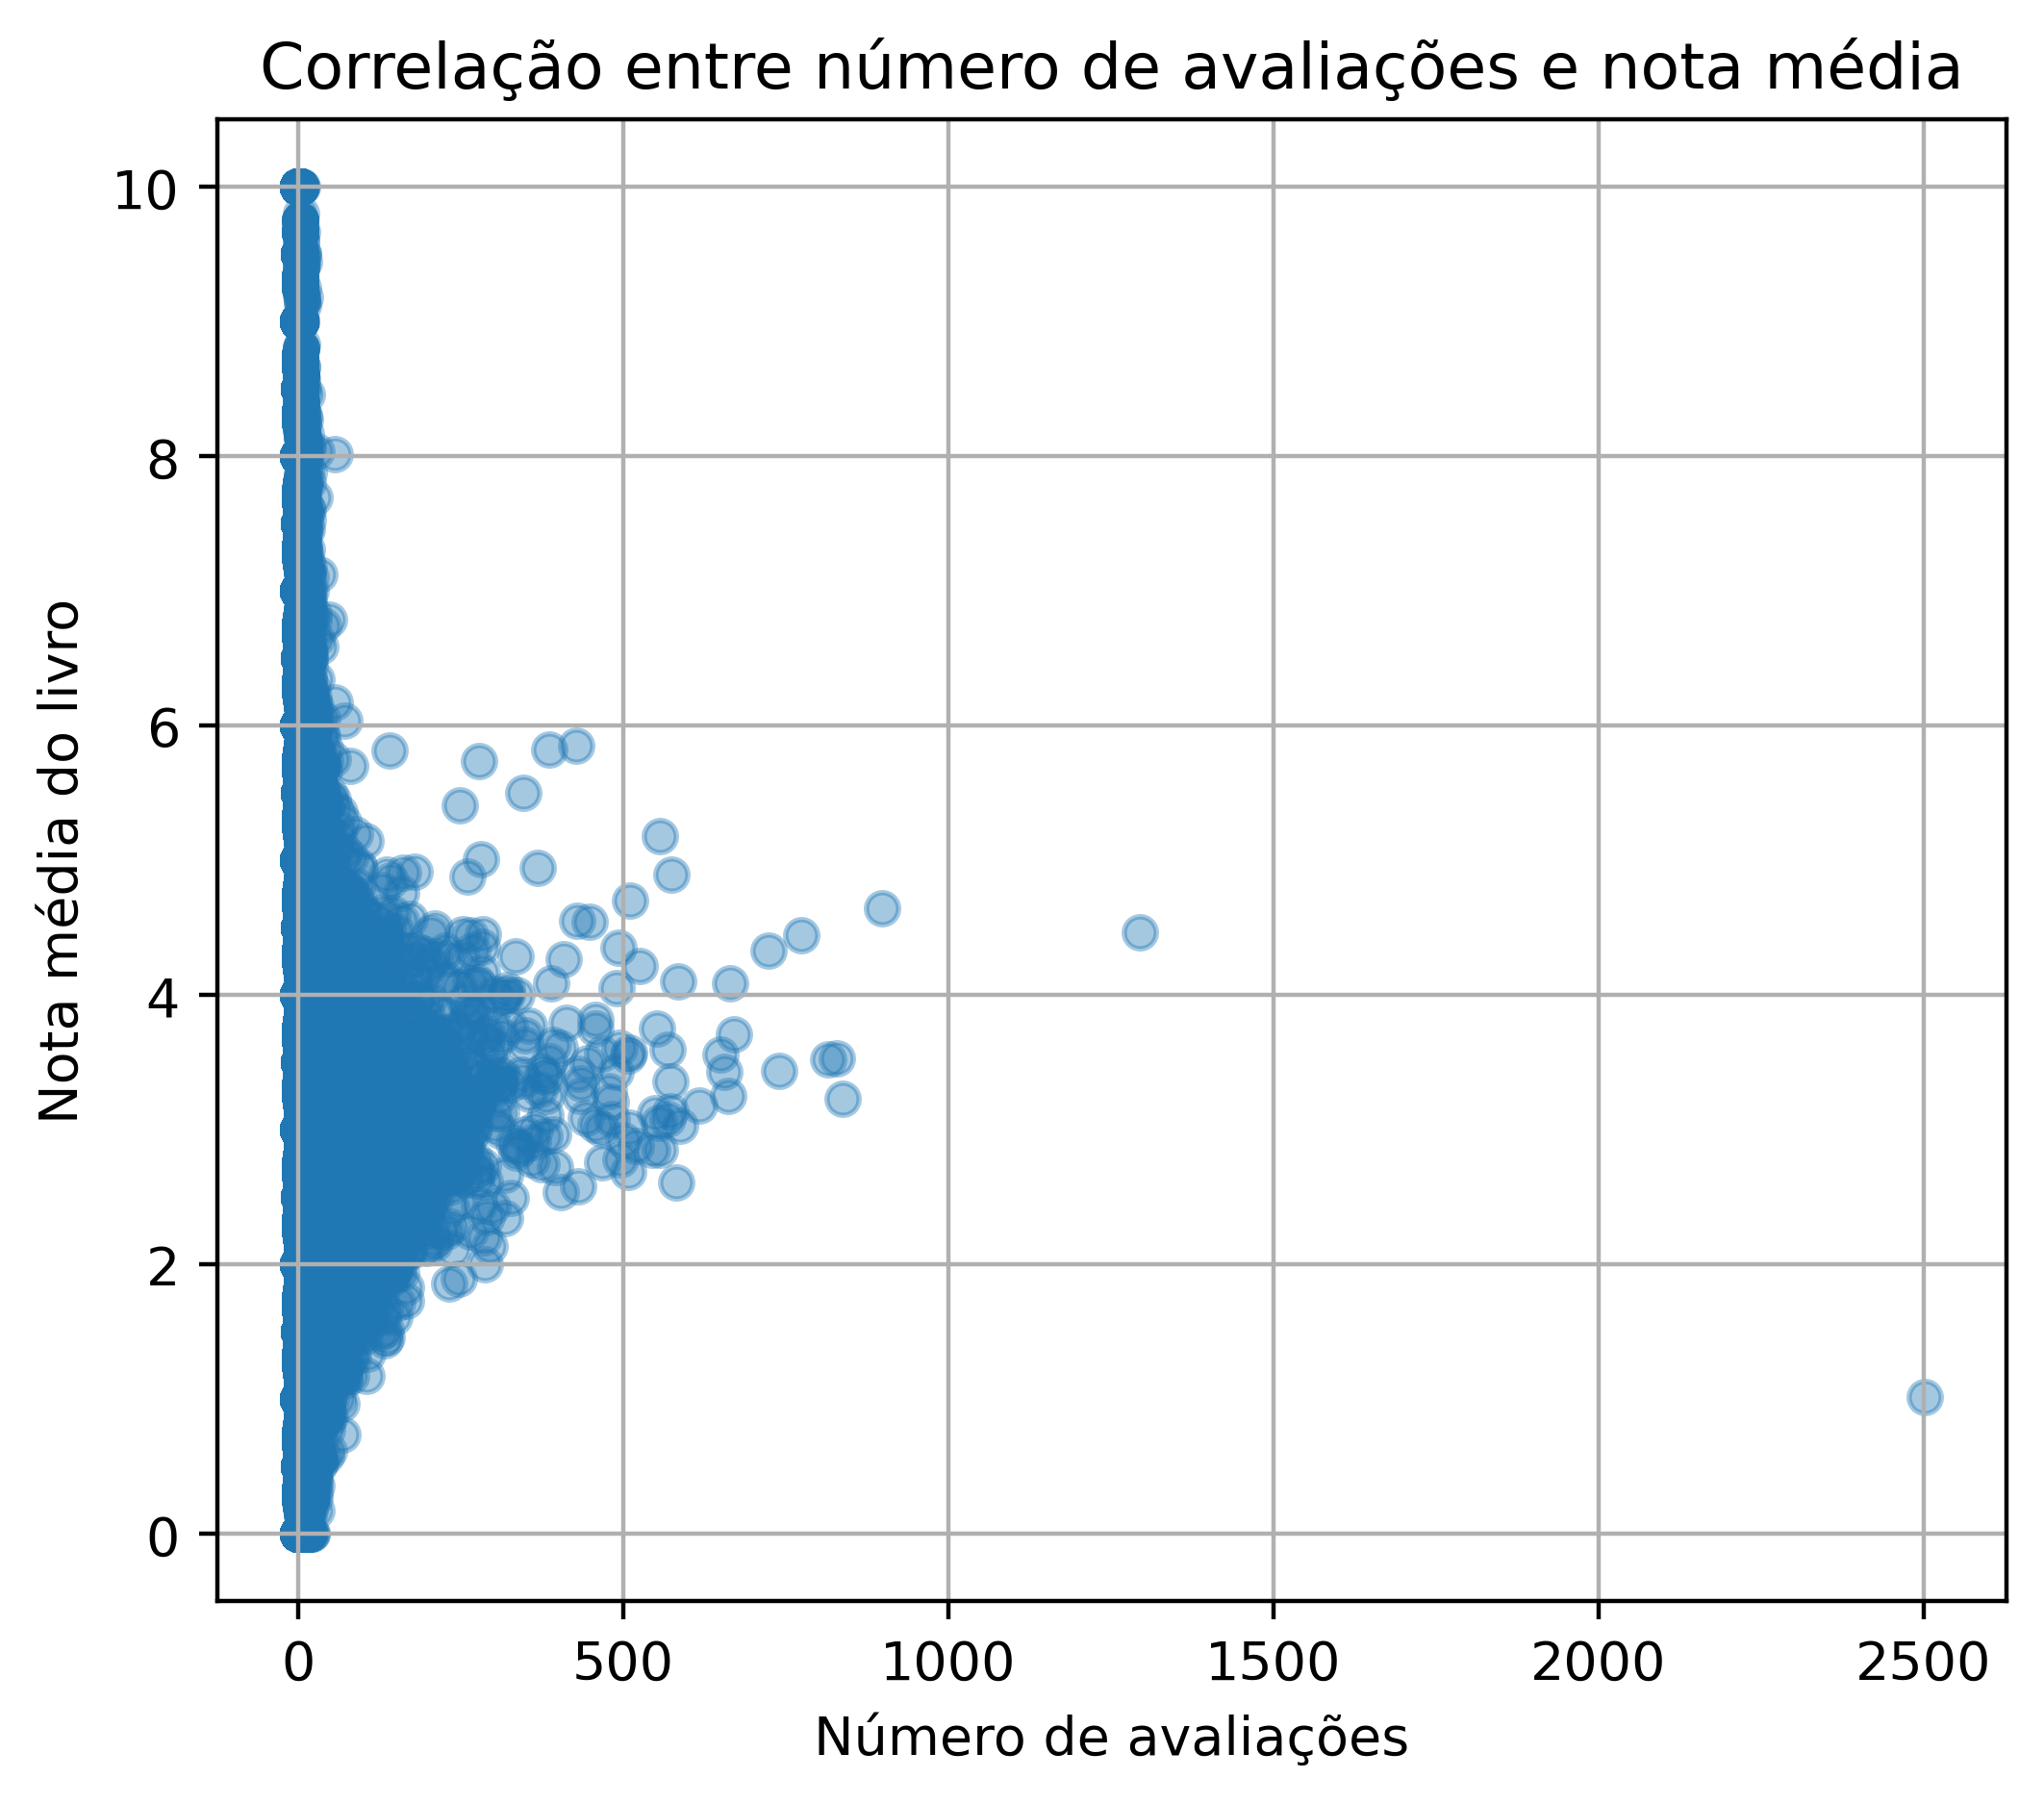

In [49]:
# ==============================================
# 6. Correlação: nº de avaliações x nota média
# ==============================================
df_corr = ratings_with_name.groupby('Book-Title').agg({
    'Book-Rating': ['count','mean']
})
df_corr.columns = ['num_ratings','avg_rating']

plt.figure(figsize=(6,5))
plt.scatter(df_corr['num_ratings'], df_corr['avg_rating'], alpha=0.4)
plt.xlabel("Número de avaliações")
plt.ylabel("Nota média do livro")
plt.title("Correlação entre número de avaliações e nota média")
plt.grid(True)
plt.show()

In [11]:
books.duplicated().sum()

0

In [12]:
users.duplicated().sum()

0

In [13]:
ratings.duplicated().sum()

0

In [14]:
books.isnull().sum()

ISBN                   0
Book-Title             0
Book-Author            2
Year-Of-Publication    0
Publisher              2
Image-URL-S            0
Image-URL-M            0
Image-URL-L            3
dtype: int64

In [15]:
users.isnull().sum()

User-ID          0
Location         0
Age         110762
dtype: int64

In [16]:
ratings.isnull().sum()

User-ID        0
ISBN           0
Book-Rating    0
dtype: int64

In [17]:
ratings_with_name = ratings.merge(books, on='ISBN')

In [18]:
num_rating_df = ratings_with_name.groupby('Book-Title').count()['Book-Rating'].reset_index()

In [19]:
num_rating_df.rename(columns={'Book-Rating':'num_ratings'}, inplace=True)

In [20]:
ratings_with_name.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1031136 entries, 0 to 1031135
Data columns (total 10 columns):
 #   Column               Non-Null Count    Dtype 
---  ------               --------------    ----- 
 0   User-ID              1031136 non-null  int64 
 1   ISBN                 1031136 non-null  object
 2   Book-Rating          1031136 non-null  int64 
 3   Book-Title           1031136 non-null  object
 4   Book-Author          1031134 non-null  object
 5   Year-Of-Publication  1031136 non-null  object
 6   Publisher            1031134 non-null  object
 7   Image-URL-S          1031136 non-null  object
 8   Image-URL-M          1031136 non-null  object
 9   Image-URL-L          1031132 non-null  object
dtypes: int64(2), object(8)
memory usage: 78.7+ MB


In [21]:
avg_rating_df = ratings_with_name.groupby('Book-Title').agg({'Book-Rating':'mean'})
avg_rating_df.rename(columns={'Book-Rating':'avg_ratings'}, inplace=True)
avg_rating_df.head(3)

,avg_ratings
Book-Title,
"A Light in the Storm: The Civil War Diary of Amelia Martin, Fenwick Island, Delaware, 1861 (Dear America)",2.25
Always Have Popsicles,0.00
Apple Magic (The Collector's series),0.00


In [22]:
popular_df = num_rating_df.merge(avg_rating_df, on='Book-Title')

In [23]:
popular_df.shape

(241071, 3)

In [24]:
popular_df = popular_df[popular_df['num_ratings'] >= 250].sort_values('avg_ratings', ascending=False).head(50)

In [25]:
popular_df = popular_df.merge(books, on='Book-Title').drop_duplicates('Book-Title')[['Book-Title','Book-Author','Image-URL-L','num_ratings','avg_ratings']]

In [26]:
popular_df

,Book-Title,Book-Author,Image-URL-L,num_ratings,avg_ratings
0,Harry Potter and the Prisoner of Azkaban (Book 3),J. K. Rowling,http://images.amazon.com/images/P/0439136350.0...,428,5.852804
3,Harry Potter and the Goblet of Fire (Book 4),J. K. Rowling,http://images.amazon.com/images/P/0439139597.0...,387,5.824289
5,Harry Potter and the Sorcerer's Stone (Book 1),J. K. Rowling,http://images.amazon.com/images/P/0590353403.0...,278,5.737410
9,Harry Potter and the Order of the Phoenix (Boo...,J. K. Rowling,http://images.amazon.com/images/P/043935806X.0...,347,5.501441
13,Harry Potter and the Chamber of Secrets (Book 2),J. K. Rowling,http://images.amazon.com/images/P/0439064872.0...,556,5.183453
16,The Hobbit : The Enchanting Prelude to The Lor...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339681.0...,281,5.007117
17,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339703.0...,368,4.948370
26,Harry Potter and the Sorcerer's Stone (Harry P...,J. K. Rowling,http://images.amazon.com/images/P/059035342X.0...,575,4.895652
28,"The Two Towers (The Lord of the Rings, Part 2)",J.R.R. TOLKIEN,http://images.amazon.com/images/P/0345339711.0...,260,4.880769
39,To Kill a Mockingbird,Harper Lee,http://images.amazon.com/images/P/0446310786.0...,510,4.700000


In [27]:
x = ratings_with_name.groupby('User-ID').count()['Book-Rating'] > 200
padhe_likhe_users = x[x].index

In [28]:
filtered_rating = ratings_with_name[ratings_with_name['User-ID'].isin(padhe_likhe_users)]

In [29]:
y = filtered_rating.groupby('Book-Title').count()['Book-Rating'] >= 50
famous_books = y[y].index

In [30]:
final_ratings = filtered_rating[filtered_rating['Book-Title'].isin(famous_books)]

In [31]:
pt = final_ratings.pivot_table(index = 'Book-Title', columns='User-ID', values='Book-Rating')

In [32]:
pt.fillna(0, inplace=True)

In [33]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_scores = cosine_similarity(pt)

In [34]:
similarity_scores

array([[1.        , 0.10255025, 0.01220856, ..., 0.12110367, 0.07347567,
        0.04316046],
       [0.10255025, 1.        , 0.2364573 , ..., 0.07446129, 0.16773875,
        0.14263397],
       [0.01220856, 0.2364573 , 1.        , ..., 0.04558758, 0.04938579,
        0.10796119],
       ...,
       [0.12110367, 0.07446129, 0.04558758, ..., 1.        , 0.07085128,
        0.0196177 ],
       [0.07347567, 0.16773875, 0.04938579, ..., 0.07085128, 1.        ,
        0.10602962],
       [0.04316046, 0.14263397, 0.10796119, ..., 0.0196177 , 0.10602962,
        1.        ]])

In [35]:
def recommend(book_name):
    index = np.where(pt.index == book_name)[0][0]
    similar_items = sorted(list(enumerate(similarity_scores[index])), key=lambda x: x[1], reverse=True)[1:6]

    for i in similar_items:
        print(pt.index[i[0]])

In [ ]:
recommend("Harry Potter and the Prisoner of Azkaban (Book 3)")

Harry Potter and the Goblet of Fire (Book 4)
Harry Potter and the Chamber of Secrets (Book 2)
Harry Potter and the Order of the Phoenix (Book 5)
Harry Potter and the Sorcerer's Stone (Book 1)
Harry Potter and the Sorcerer's Stone (Harry Potter (Paperback))



🎯 LIVRO SELECIONADO:
📖 Harry Potter and the Prisoner of Azkaban (Book 3)
👤 J. K. Rowling
⭐ 5.9 • 📊 428 avaliações

🔍 Buscando recomendações...

🎁 RECOMENDAÇÕES (AUTORES DIFERENTES)
The Lovely Bones: A Novel
   👤 Alice Sebold
   ⭐ 4.5 • 📊 1295 avaliações
The Da Vinci Code
   👤 Dan Brown
   ⭐ 4.6 • 📊 898 avaliações
The Secret Life of Bees
   👤 Sue Monk Kidd
   ⭐ 4.4 • 📊 774 avaliações
The Red Tent (Bestselling Backlist)
   👤 Anita Diamant
   ⭐ 4.3 • 📊 723 avaliações
Life of Pi
   👤 Yann Martel
   ⭐ 4.1 • 📊 664 avaliações


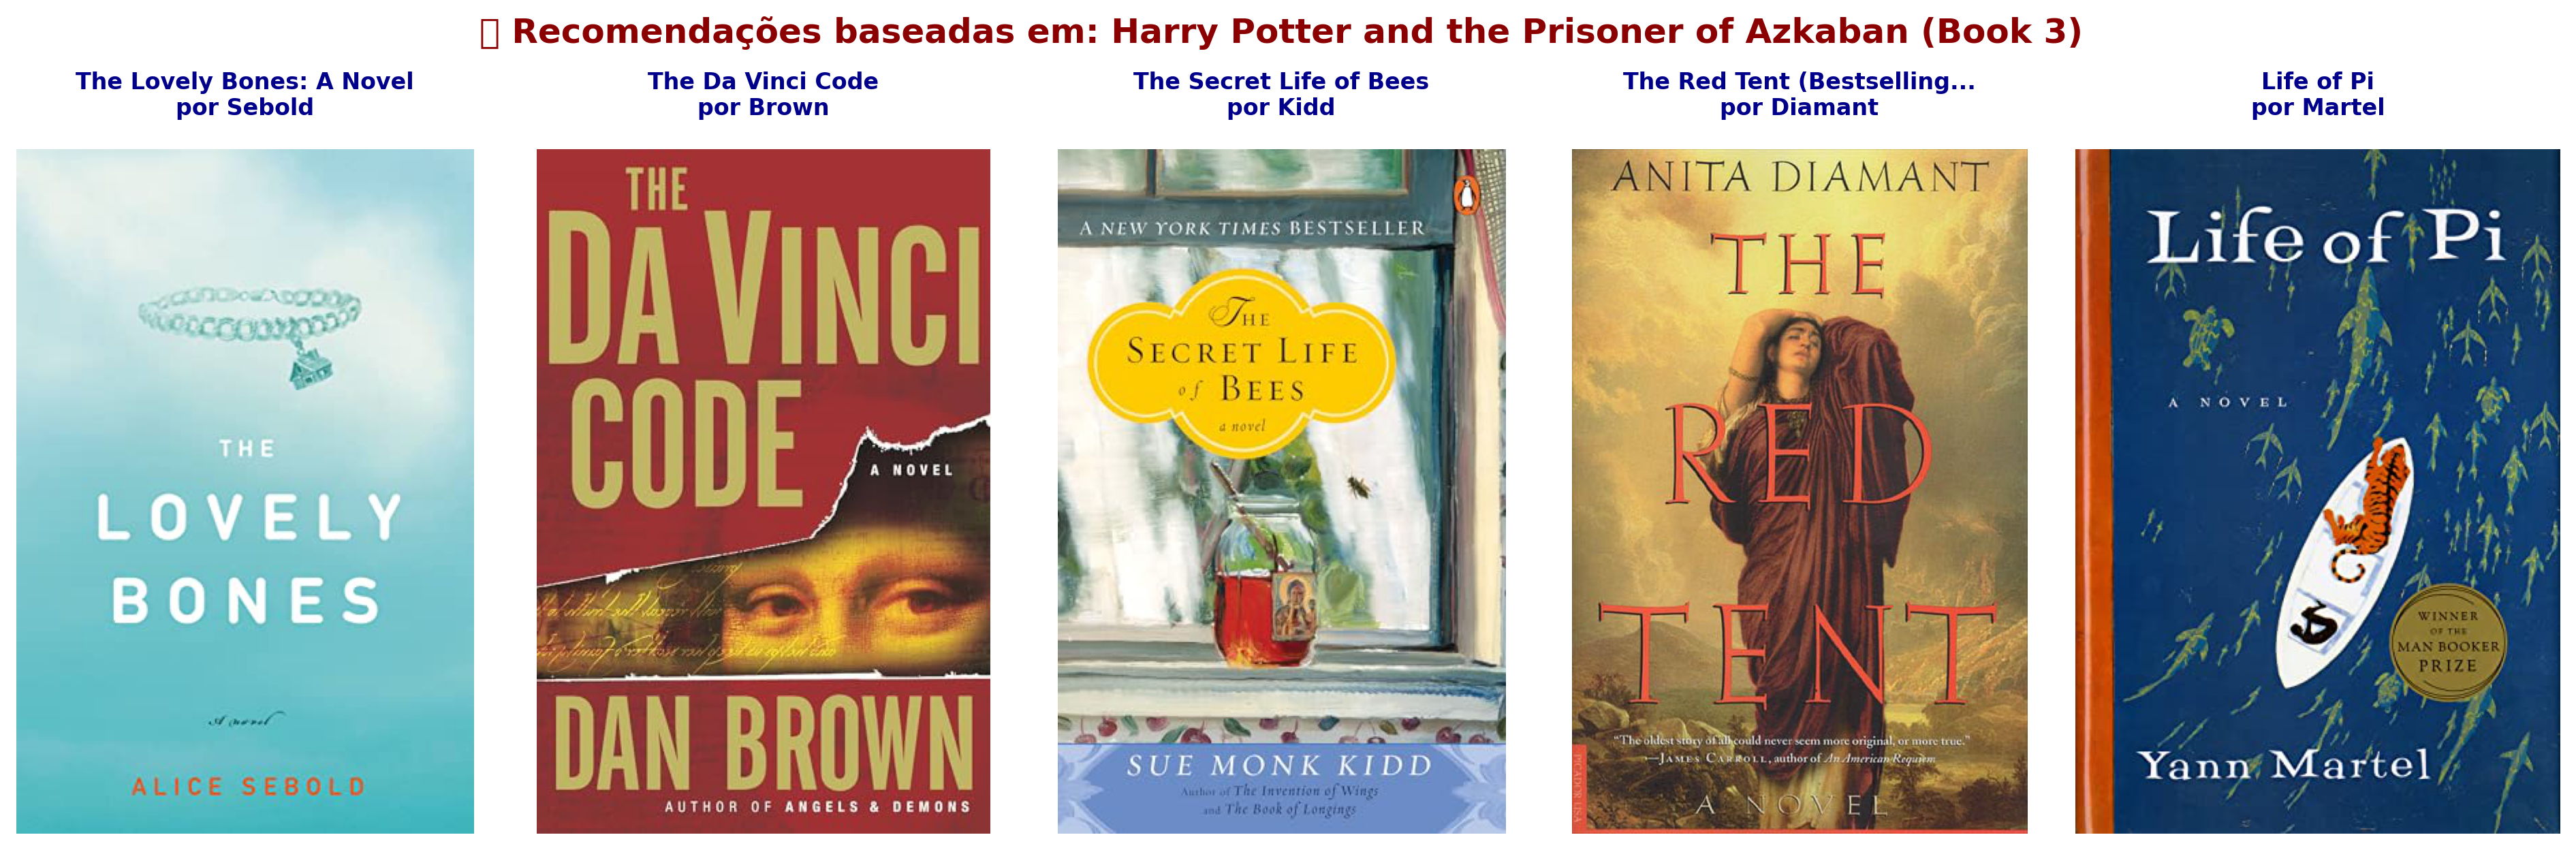

,Book-Title,Book-Author,Image-URL-L,num_ratings,avg_ratings
62,The Lovely Bones: A Novel,Alice Sebold,http://images.amazon.com/images/P/0316666343.0...,1295,4.468726
47,The Da Vinci Code,Dan Brown,http://images.amazon.com/images/P/0385504209.0...,898,4.642539
78,The Secret Life of Bees,Sue Monk Kidd,http://images.amazon.com/images/P/0142001740.0...,774,4.447028
88,The Red Tent (Bestselling Backlist),Anita Diamant,http://images.amazon.com/images/P/0312195516.0...,723,4.334716
126,Life of Pi,Yann Martel,http://images.amazon.com/images/P/0151008116.0...,664,4.088855


In [37]:
# ============================================
# 🔹 Execução de teste
# ============================================
robust_recommendations("Harry Potter and the Prisoner of Azkaban (Book 3)", popular_df)

In [38]:
# 📏 RMSE e MAE (baseline por média do livro)
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error


def _avaliar_rmse_mae(df_ratings, book_col='Book-Title', rating_col='Book-Rating'):
    preds, trues = [], []
    for titulo, grupo in df_ratings.groupby(book_col):
        m = grupo[rating_col].mean()
        preds.extend([m]*len(grupo))
        trues.extend(grupo[rating_col].tolist())
    rmse = float(np.sqrt(mean_squared_error(trues, preds)))
    mae  = float(mean_absolute_error(trues, preds))
    return rmse, mae

rmse = mae = None
try:
    if 'final_ratings' in globals() and not final_ratings.empty:
        rmse, mae = _avaliar_rmse_mae(final_ratings)
    elif 'ratings_with_name' in globals() and not ratings_with_name.empty:
        rmse, mae = _avaliar_rmse_mae(ratings_with_name)
    else:
        raise NameError('Nenhum dataframe conhecido para avaliação encontrado.')
    print(f'RMSE: {rmse:.3f} | MAE: {mae:.3f}')
except Exception as e:
    print('Falha ao calcular RMSE/MAE:', e)

RMSE: 3.481 | MAE: 2.875


In [62]:
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# ==============================
# 🔹 Base para avaliação
# ==============================

# use final_ratings se existir, senão cai para ratings_with_name
try:
    df_eval = final_ratings.copy()
except NameError:
    df_eval = ratings_with_name.copy()

# baseline: média das notas por livro como "score" de previsão
book_mean = df_eval.groupby('Book-Title')['Book-Rating'].mean().rename('pred_mean')
df_eval = df_eval.join(book_mean, on='Book-Title')

# verdadeiro (real) e previsto (regressão)
y_true_reg = df_eval['Book-Rating'].values
y_pred_reg = df_eval['pred_mean'].values

# transforma em problema binário (gosto / não gosto)
# você pode mudar esse limiar se quiser
threshold_like = 7
y_true_bin = (df_eval['Book-Rating'] >= threshold_like).astype(int)
y_scores = y_pred_reg  # usamos a média prevista como score

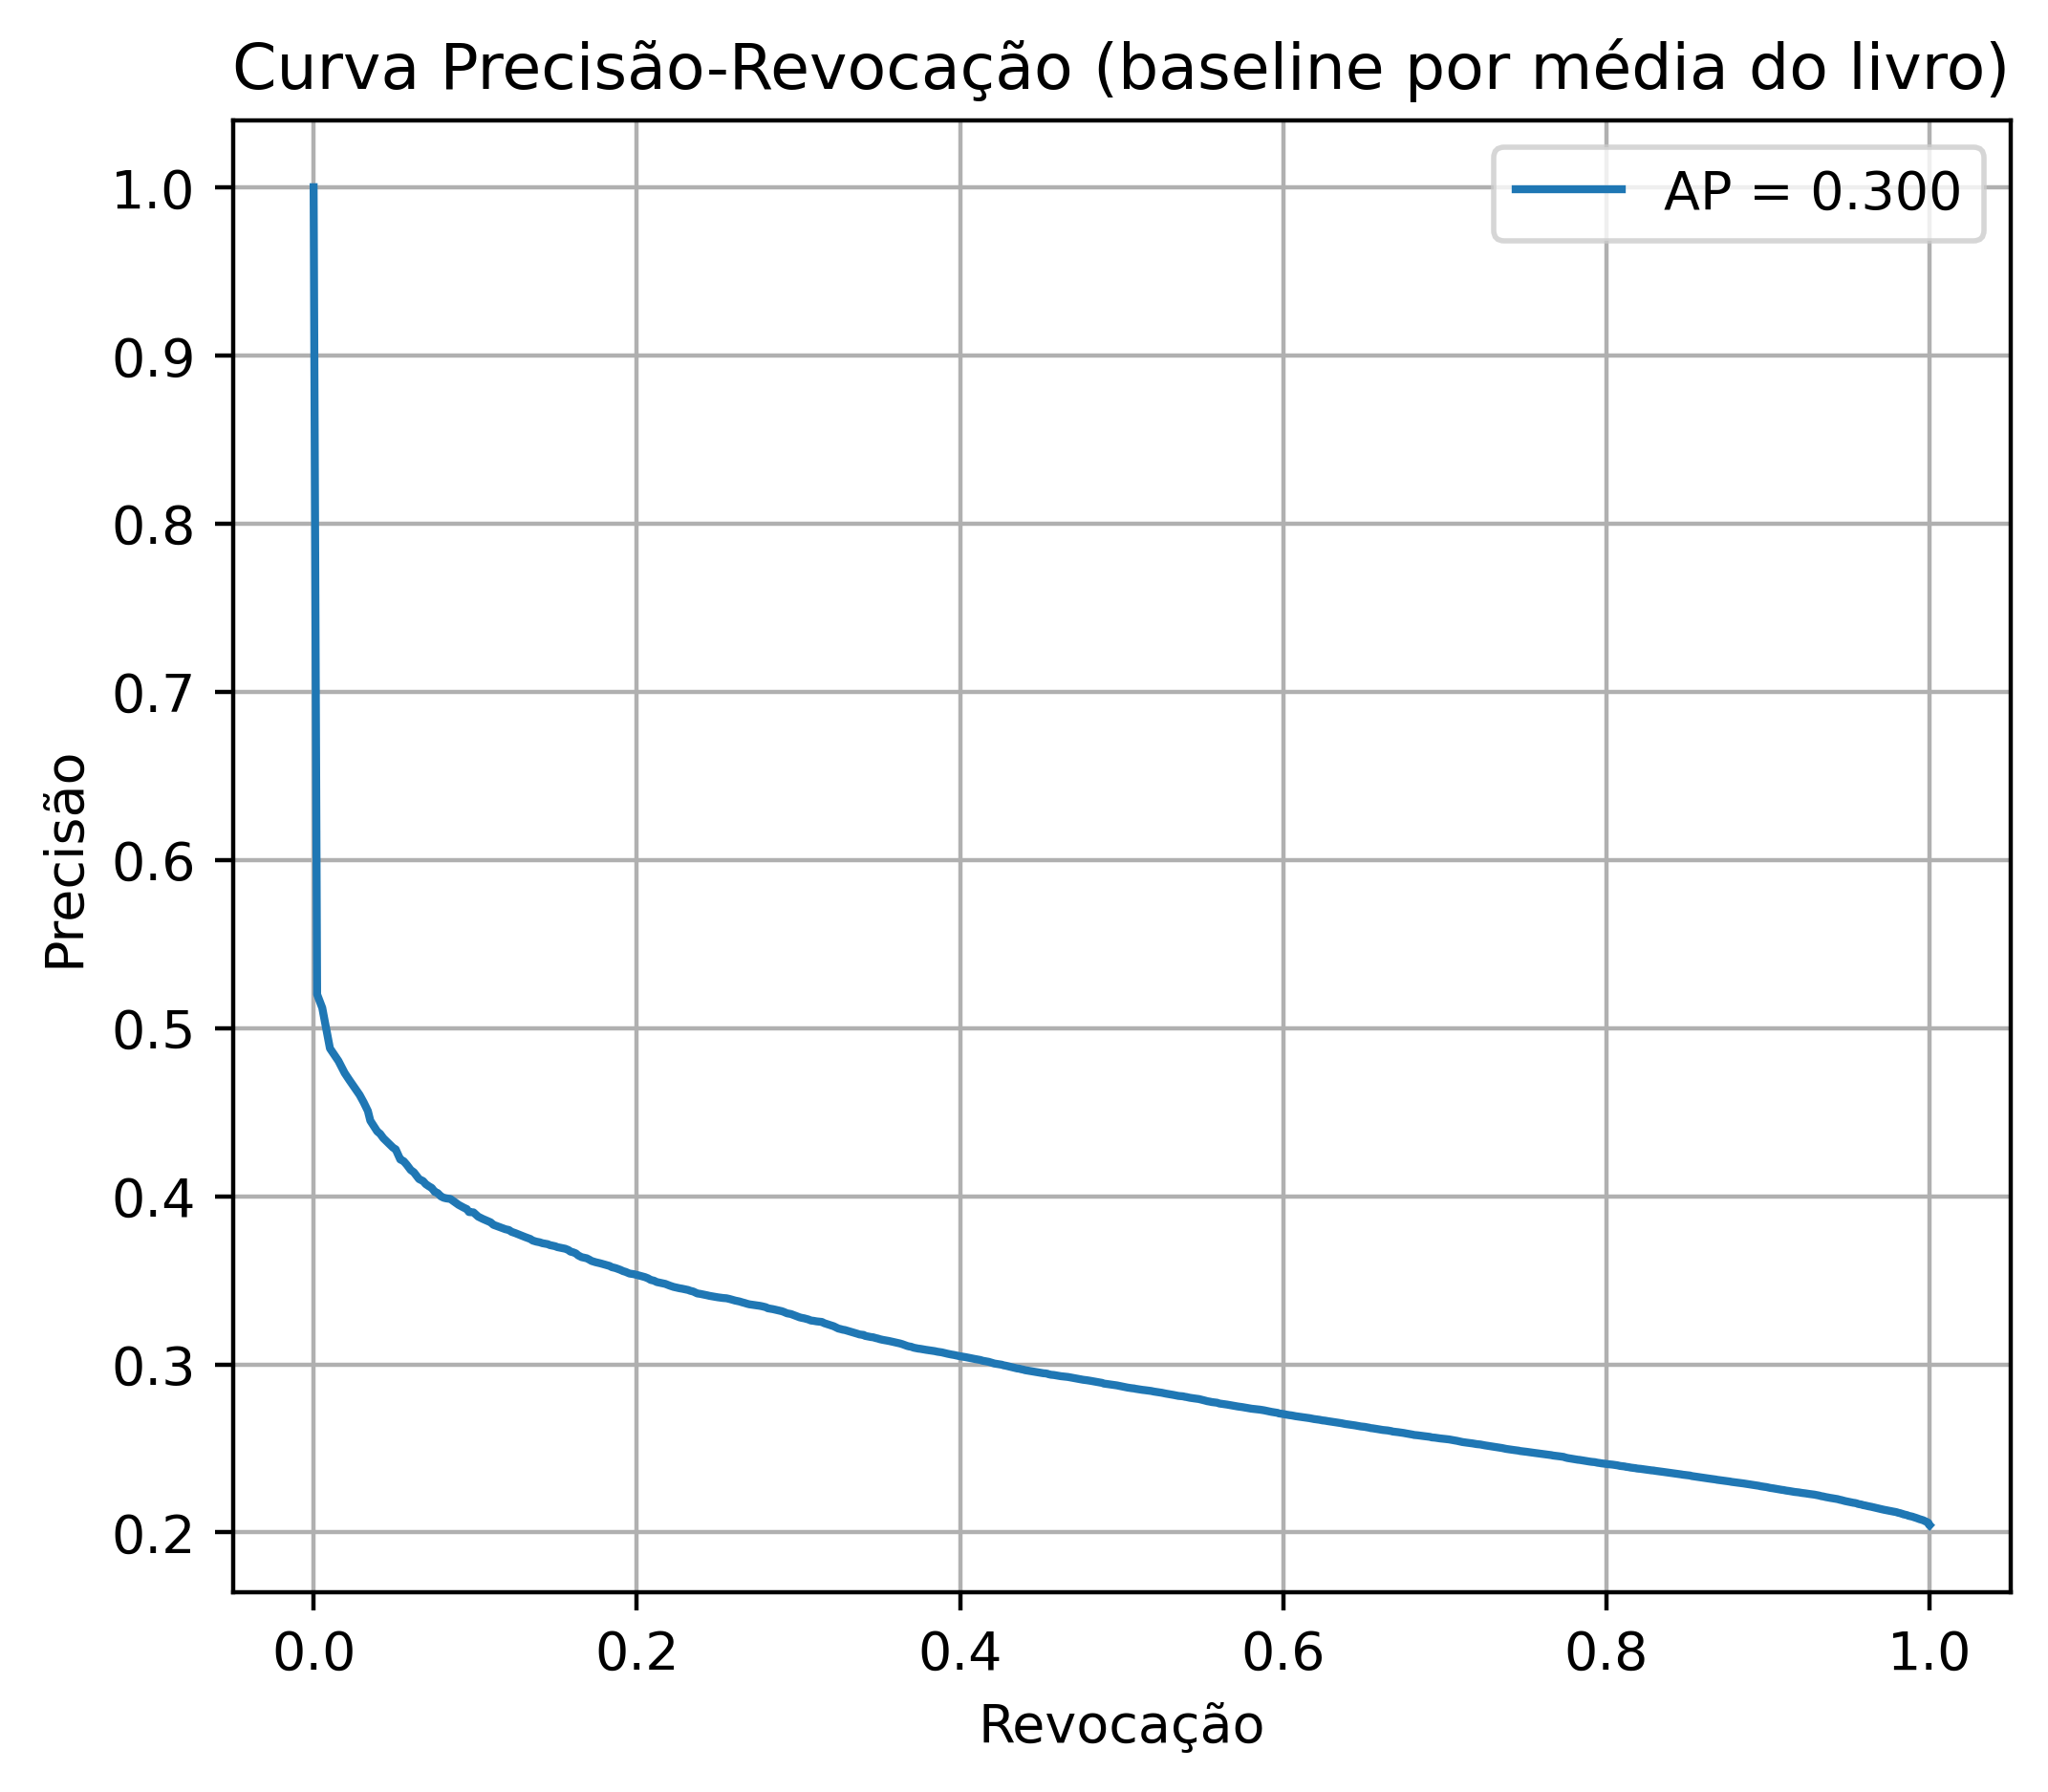

In [63]:
# ==============================
# 🔹 Curva Precisão-Revocação
# ==============================

precision, recall, _ = precision_recall_curve(y_true_bin, y_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(6, 5))
plt.plot(recall, precision, label=f'AP = {pr_auc:.3f}')
plt.xlabel('Revocação')
plt.ylabel('Precisão')
plt.title('Curva Precisão-Revocação (baseline por média do livro)')
plt.legend()
plt.grid(True)
plt.show()

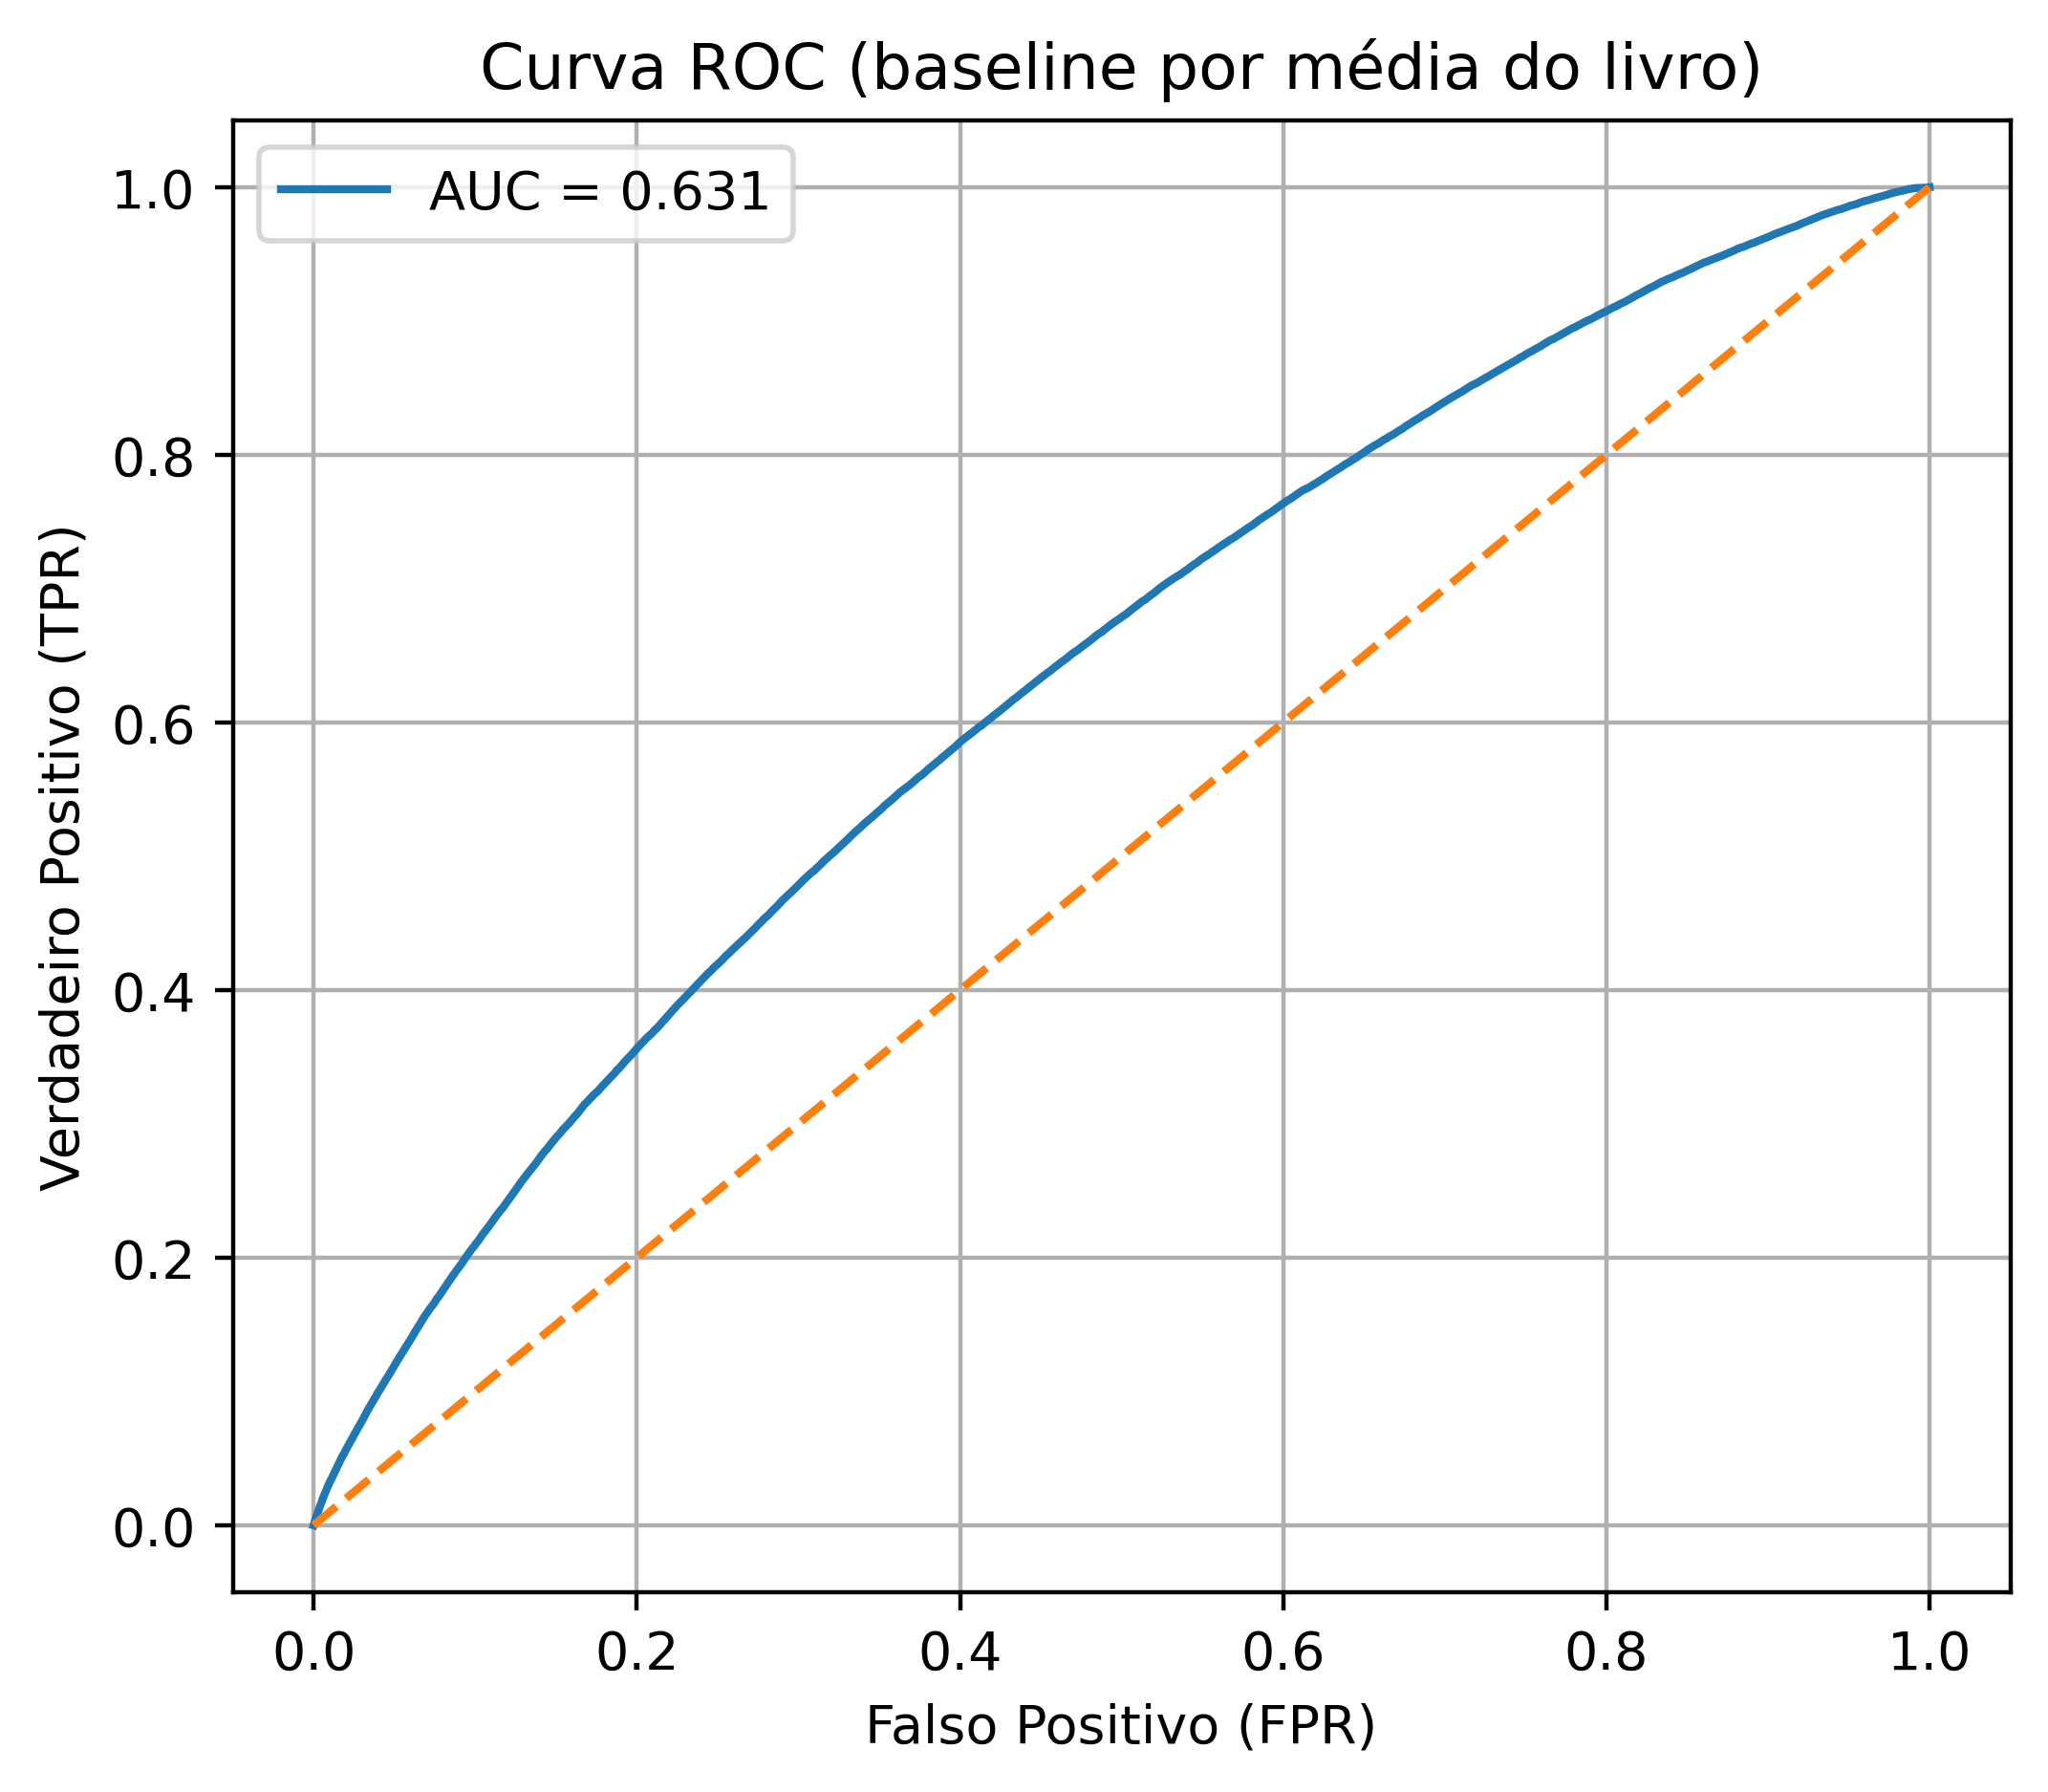

In [64]:
# ==============================
# 🔹 Curva ROC
# ==============================

fpr, tpr, _ = roc_curve(y_true_bin, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], linestyle='--')  # linha aleatória
plt.xlabel('Falso Positivo (FPR)')
plt.ylabel('Verdadeiro Positivo (TPR)')
plt.title('Curva ROC (baseline por média do livro)')
plt.legend()
plt.grid(True)
plt.show()

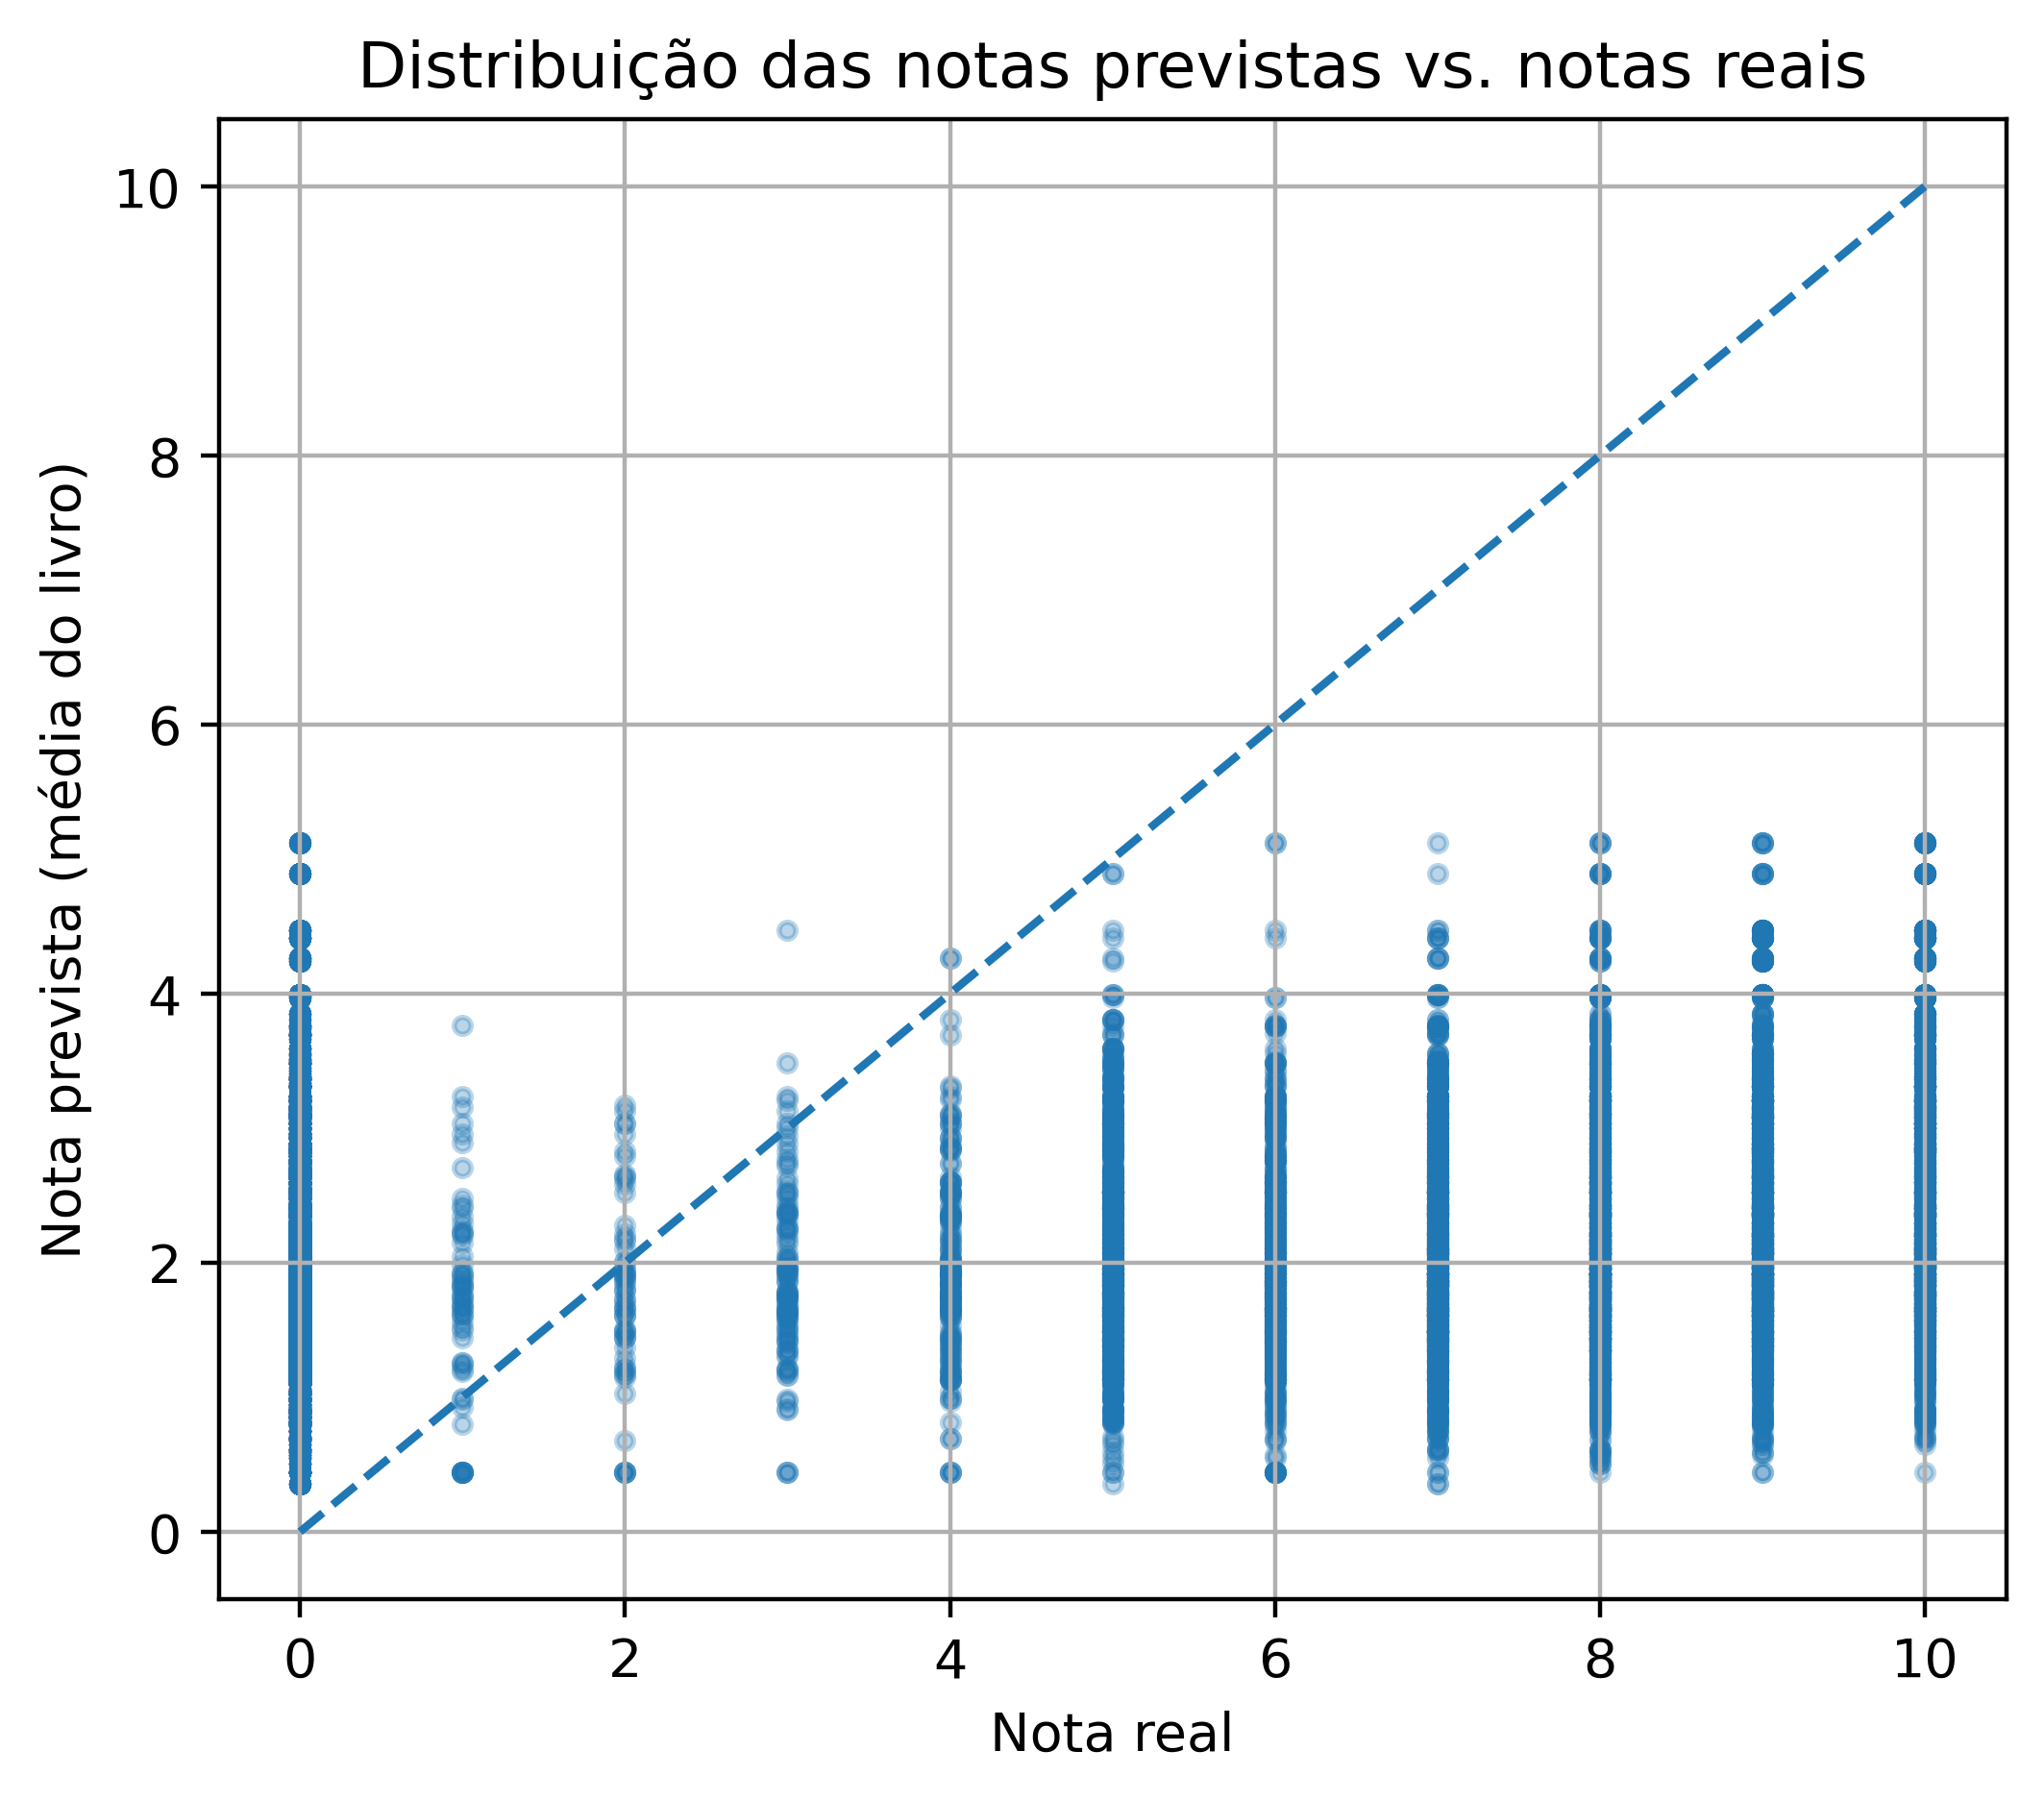

In [65]:
# Scatter: previsto x real
plt.figure(figsize=(6, 5))
plt.scatter(y_true_reg, y_pred_reg, alpha=0.3, s=10)
min_v = min(y_true_reg.min(), y_pred_reg.min())
max_v = max(y_true_reg.max(), y_pred_reg.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle='--')  # linha ideal
plt.xlabel('Nota real')
plt.ylabel('Nota prevista (média do livro)')
plt.title('Distribuição das notas previstas vs. notas reais')
plt.grid(True)
plt.show()


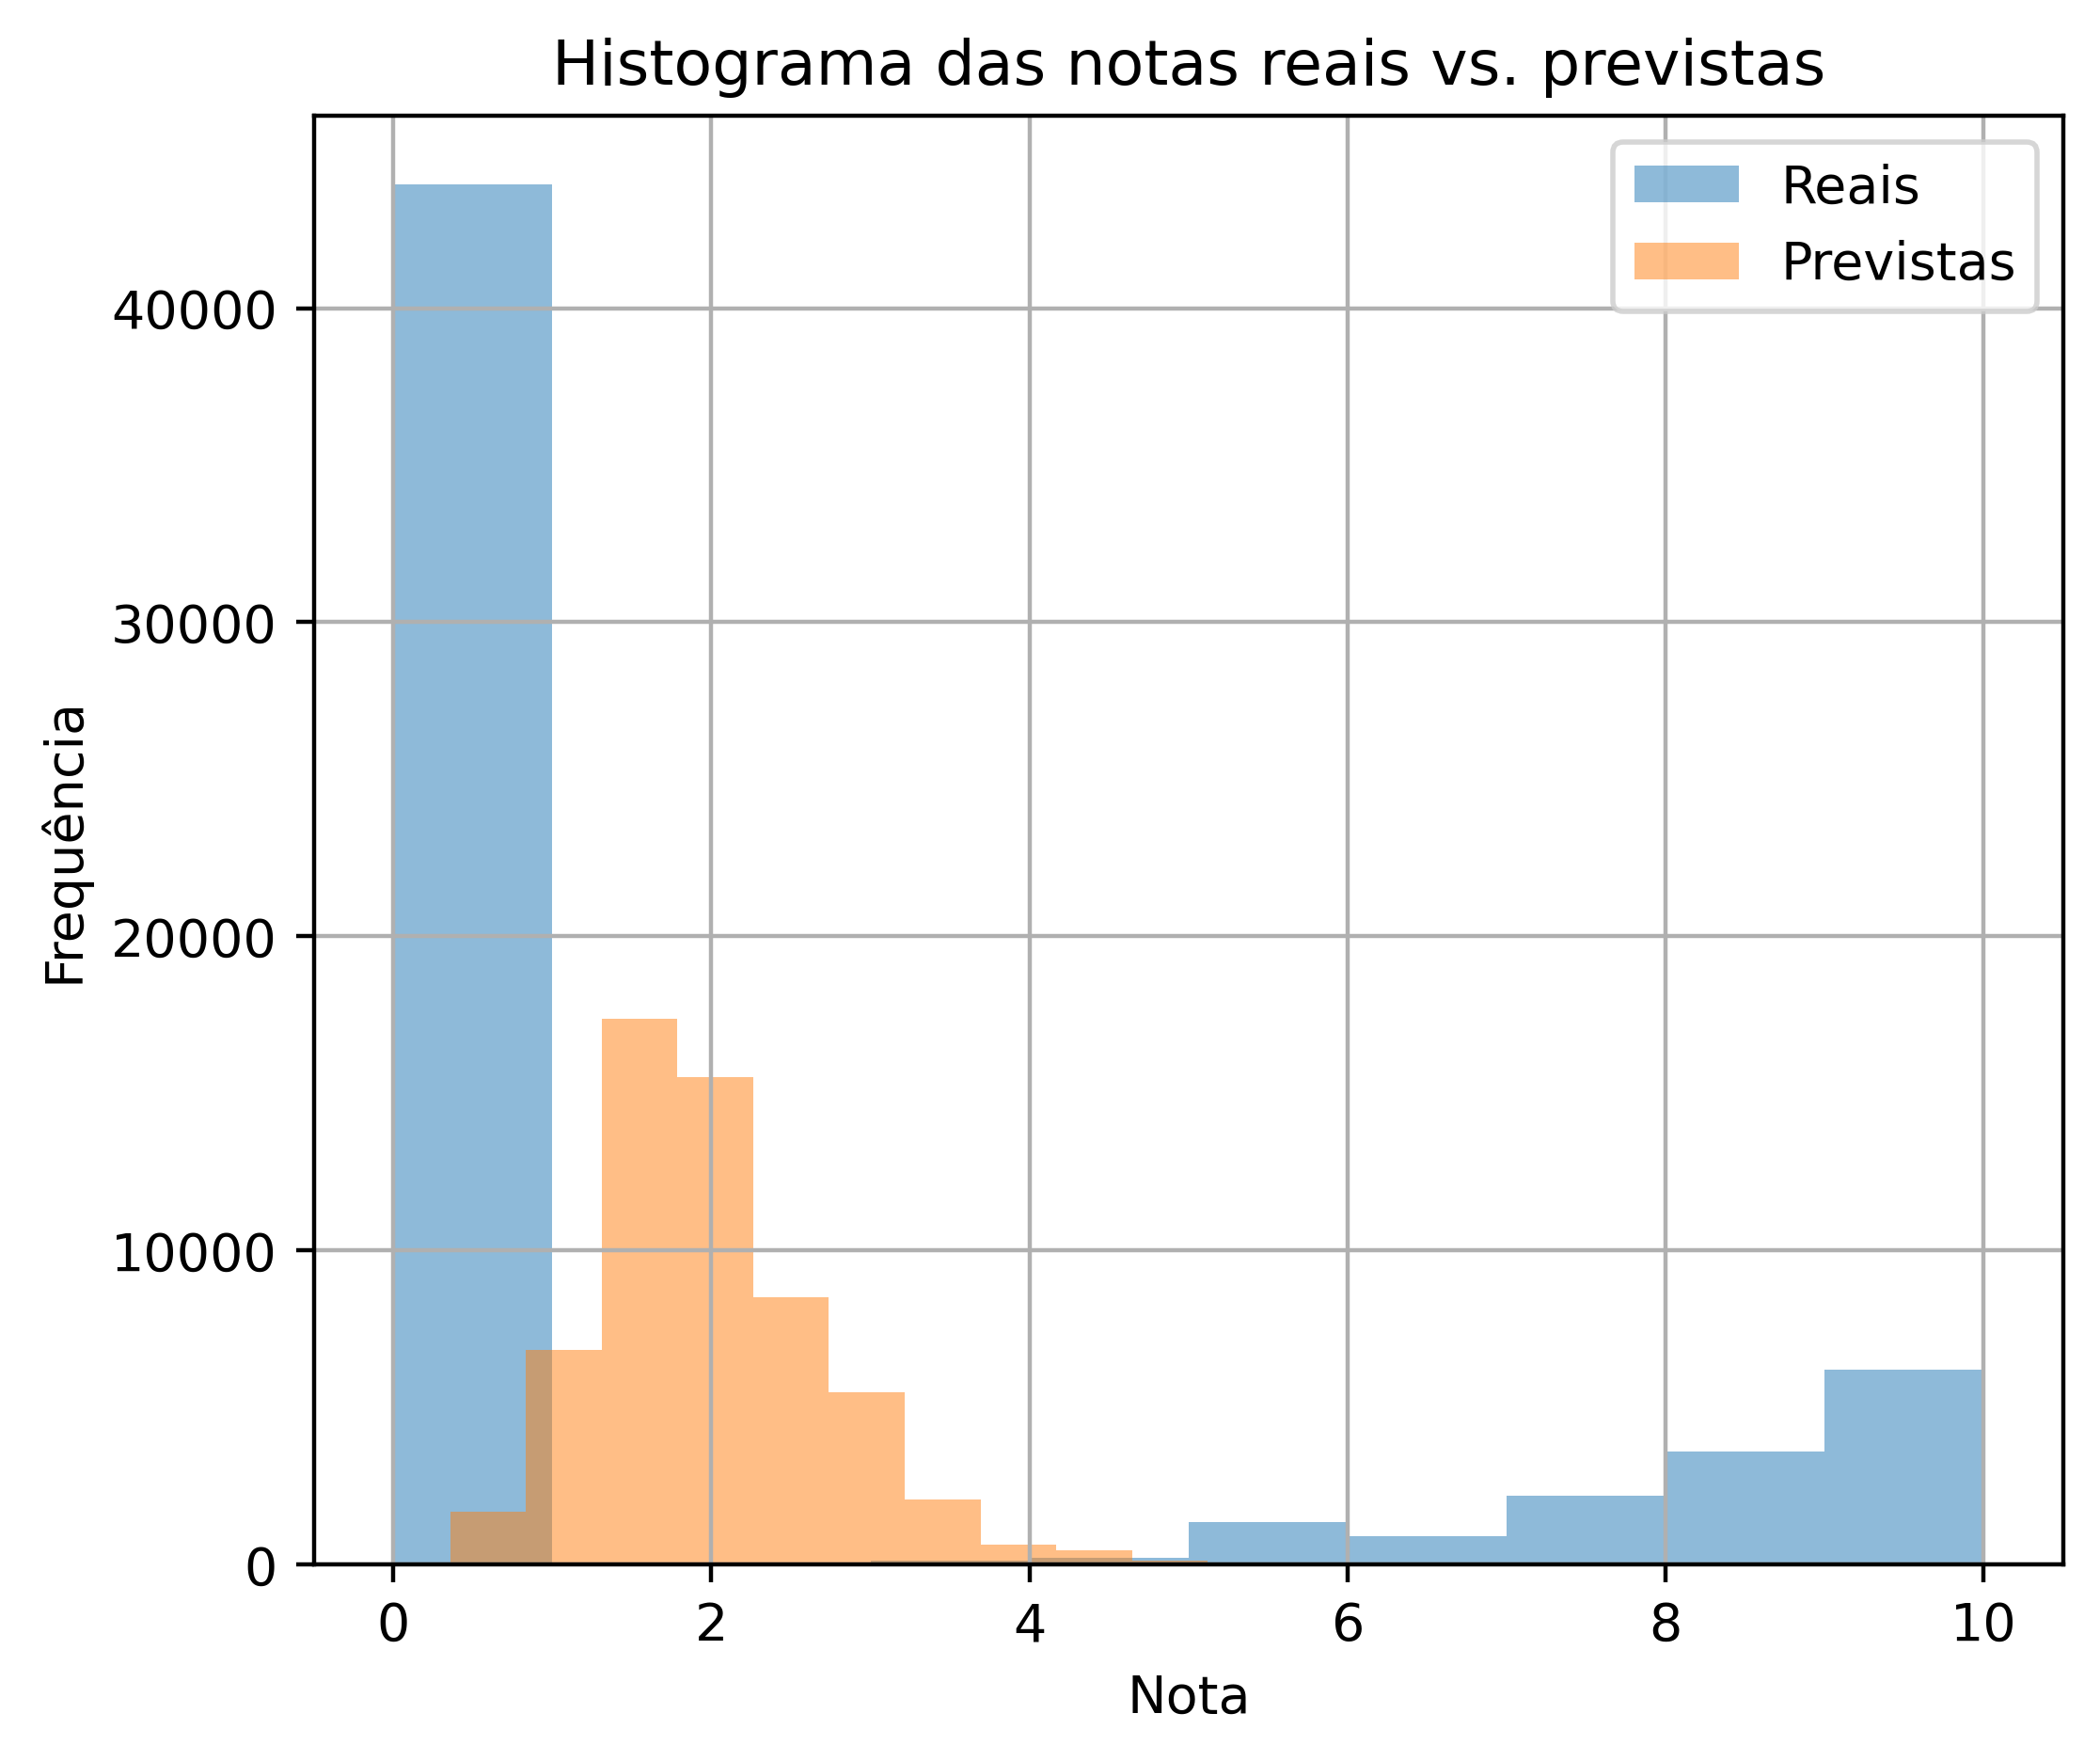

In [66]:
plt.figure(figsize=(6, 5))
plt.hist(y_true_reg, bins=10, alpha=0.5, label='Reais')
plt.hist(y_pred_reg, bins=10, alpha=0.5, label='Previstas')
plt.xlabel('Nota')
plt.ylabel('Frequência')
plt.title('Histograma das notas reais vs. previstas')
plt.legend()
plt.grid(True)
plt.show()

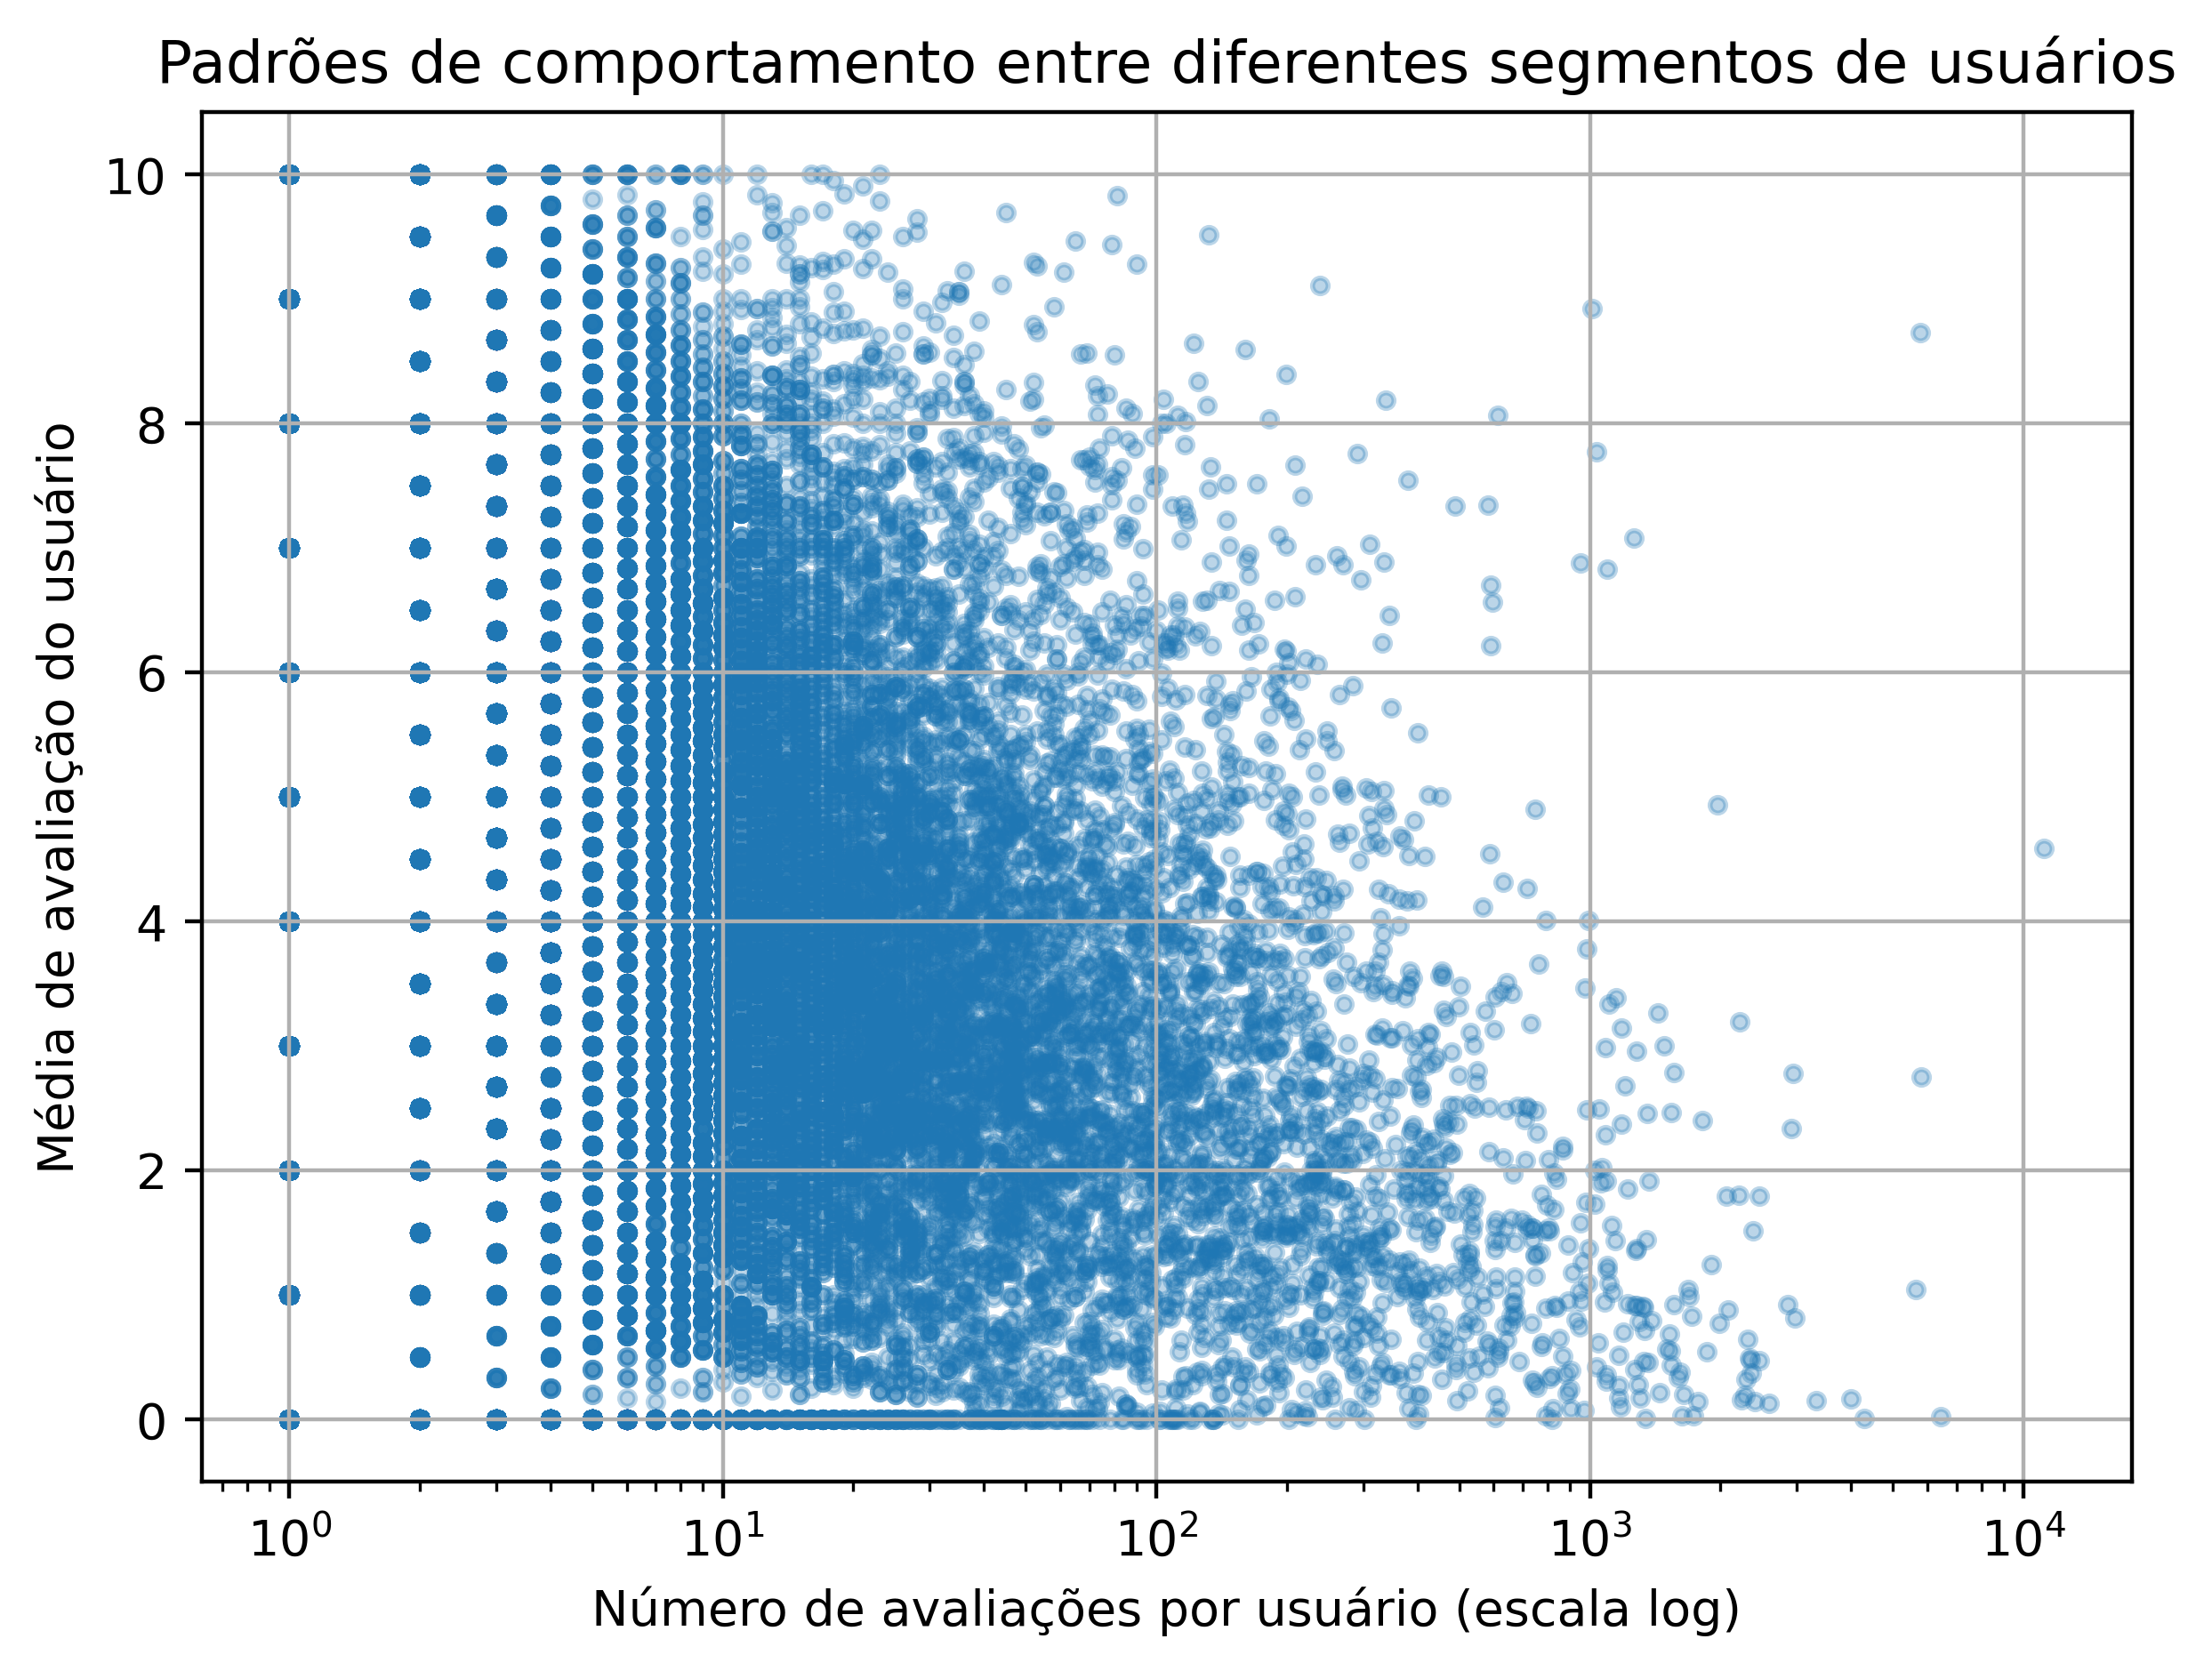

: 

In [ ]:
# estatísticas por usuário
user_stats = ratings_with_name.groupby('User-ID')['Book-Rating'].agg(['count', 'mean']).reset_index()

plt.figure(figsize=(7, 5))
plt.scatter(user_stats['count'], user_stats['mean'], alpha=0.3, s=10)
plt.xscale('log')  # log para separar melhor quem avalia muito
plt.xlabel('Número de avaliações por usuário (escala log)')
plt.ylabel('Média de avaliação do usuário')
plt.title('Padrões de comportamento entre diferentes segmentos de usuários')
plt.grid(True)
plt.show()
